# 1. Setup

## 1.1 Library

In [1]:
import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from scipy.stats import chi2_contingency, kruskal
from statsmodels.stats.outliers_influence import variance_inflation_factor

from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
# from cuml.ensemble import RandomForestClassifier as cuRF

from time import time

from sklearn.metrics import classification_report, roc_auc_score, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_curve

import shap
import joblib

In [2]:
SEED = 42

## 1.2 Load Data 
load 500k data, need more time to load it

In [3]:
df = pd.read_excel("/kaggle/input/datasets/tungstor1/online-retail-dataset/Online Retail.xlsx")

# 2. Data Overview

## 2.1 Data Structure

In [4]:
print(df.shape)
df.head()

(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  float64       
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 33.1+ MB


## 2.2 Data Casting

In [6]:
print("Num of Customer: ", df['CustomerID'].nunique())

Num of Customer:  4372


In [7]:
df['CustomerID'] = df['CustomerID'].astype('str')
df['CustomerID'] = df['CustomerID'].replace('nan', np.nan)
print("CustomerID after casting:", df['CustomerID'].nunique())
df.info()

CustomerID after casting: 4372
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB


## 2.3 Numeric Summary & Anomaly Check

In [8]:
df.describe()

,Quantity,InvoiceDate,UnitPrice
count,541909.000000,541909,541909.000000
mean,9.552250,2011-07-04 13:34:57.156386048,4.611114
min,-80995.000000,2010-12-01 08:26:00,-11062.060000
25%,1.000000,2011-03-28 11:34:00,1.250000
50%,3.000000,2011-07-19 17:17:00,2.080000
75%,10.000000,2011-10-19 11:27:00,4.130000
max,80995.000000,2011-12-09 12:50:00,38970.000000
std,218.081158,NaN,96.759853


In [9]:
(df['Quantity'] <= 0).sum()

np.int64(10624)

In [10]:
(df['UnitPrice'] <= 0).sum()

np.int64(2517)

In [11]:
print(df['Description'][df['Quantity'] <= 0].value_counts())
print()
print(df['Description'][df['UnitPrice'] <= 0].value_counts())

Description
Manual                              244
REGENCY CAKESTAND 3 TIER            181
POSTAGE                             126
check                               120
JAM MAKING SET WITH JARS             87
                                   ... 
FOLKART ZINC HEART CHRISTMAS DEC      1
BOYS ALPHABET IRON ON PATCHES         1
LIPSTICK PEN RED                      1
???                                   1
36 PENCILS TUBE SKULLS                1
Name: count, Length: 2110, dtype: int64

Description
check                             159
?                                  47
damages                            45
damaged                            43
found                              25
                                 ... 
CHILDREN'S APRON DOLLY GIRL         1
MINI LIGHTS WOODLAND MUSHROOMS      1
water damaged                       1
SET OF 9 BLACK SKULL BALLOONS       1
PAPER BUNTING VINTAGE PAISLEY       1
Name: count, Length: 377, dtype: int64


# 3. Data Cleaning & Flagging

## 3.1 Trancastion Flags

In [12]:
df['InvoiceType'] = 'Normal'
df.loc[(df['InvoiceNo'].astype(str).str.startswith('C')) & (~df['StockCode'].astype(str).str.isalpha()), 'InvoiceType'] = 'Cancellation'
df.loc[df['InvoiceNo'].astype(str).str.startswith('A'), 'InvoiceType'] = 'Adjustment'

df['IsValidPrice'] = df['UnitPrice'] > 0
df['HasDescription'] = df['Description'].notna()

In [13]:
cond_alpha = df['StockCode'].astype(str).str.isalpha()
cond_anomaly = (df['Quantity'] <= 0) | (df['UnitPrice'] <= 0)

non_product_codes = df.loc[cond_alpha & cond_anomaly, 'StockCode'].unique()

df['IsProduct'] = ~df['StockCode'].isin(non_product_codes)

In [14]:
df['DataQualityFlag'] = np.select(
    [
        df['InvoiceType'] != 'Normal',
        ~df['IsProduct'],
        ~df['IsValidPrice'],
        ~df['HasDescription'],
    ],
    ['Cancellation/Adjustment', 'Non-product entry', 'Invalid price', 'Missing description'],
    default='Clean'
) if hasattr(np, 'select') else None

In [15]:
df['IsProduct'].value_counts()

IsProduct
True     539175
False      2734
Name: count, dtype: int64

## 3.2 Duplicates

In [16]:
print(df.duplicated().sum())

5268


In [17]:
df.drop_duplicates(inplace = True)
print(df.duplicated().sum())

0


## 3.3 Missing Values

In [18]:
df.isna().sum()

InvoiceNo               0
StockCode               0
Description          1454
Quantity                0
InvoiceDate             0
UnitPrice               0
CustomerID         135037
Country                 0
InvoiceType             0
IsValidPrice            0
HasDescription          0
IsProduct               0
DataQualityFlag         0
dtype: int64

In [19]:
# df = df.dropna().copy()
# print(f"Data after dropna: {df.shape}")
# print(f"Data that get drop: {len(df) - len(df)}")
# print(df.isna().sum())

## 3.4 Outliers

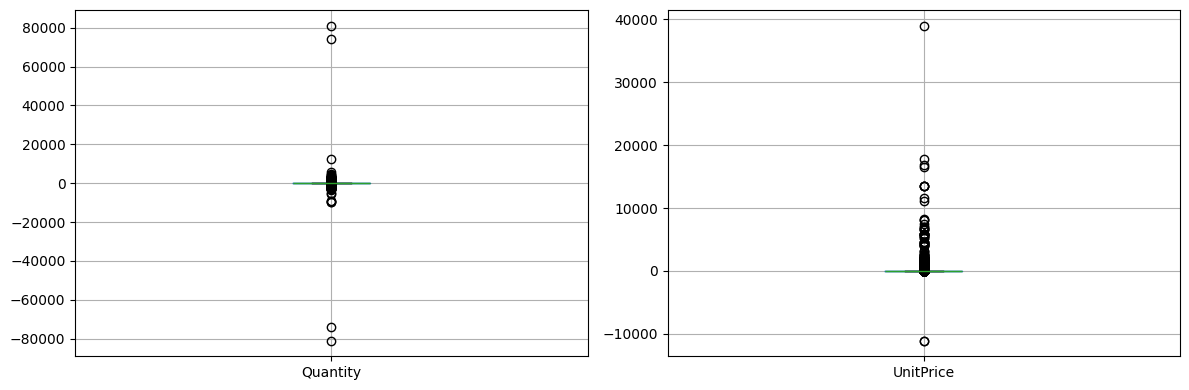

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
df.boxplot(column='Quantity', ax=axes[0])
df.boxplot(column='UnitPrice', ax=axes[1])
plt.tight_layout()
plt.show()

Ditemukan ada outlier pada data Quntity yang besarnya positif dan negatif, menandakan barang yang terjual (positif) dan barang yang diretur (negatif)

# 4. Feature Engineering & Working Data

## 4.1 Derived Columns

In [21]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

## 4.2 Product Dataset (df_product)

In [22]:
df_product = df[
    df['IsProduct'] &
    df['HasDescription'] &
    (df['InvoiceType'] == 'Normal')
].copy()

In [23]:
print(df_product.shape)
df_product.head()

(523769, 16)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,InvoiceType,IsValidPrice,HasDescription,IsProduct,DataQualityFlag,Revenue,InvoiceMonth,DayOfWeek
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,Normal,True,True,True,Clean,15.30,2010-12,Wednesday
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Normal,True,True,True,Clean,20.34,2010-12,Wednesday
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,Normal,True,True,True,Clean,22.00,2010-12,Wednesday
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Normal,True,True,True,Clean,20.34,2010-12,Wednesday
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,Normal,True,True,True,Clean,20.34,2010-12,Wednesday


In [24]:
df_product.info()

<class 'pandas.core.frame.DataFrame'>
Index: 523769 entries, 0 to 541908
Data columns (total 16 columns):
 #   Column           Non-Null Count   Dtype         
---  ------           --------------   -----         
 0   InvoiceNo        523769 non-null  object        
 1   StockCode        523769 non-null  object        
 2   Description      523769 non-null  object        
 3   Quantity         523769 non-null  int64         
 4   InvoiceDate      523769 non-null  datetime64[ns]
 5   UnitPrice        523769 non-null  float64       
 6   CustomerID       391328 non-null  object        
 7   Country          523769 non-null  object        
 8   InvoiceType      523769 non-null  object        
 9   IsValidPrice     523769 non-null  bool          
 10  HasDescription   523769 non-null  bool          
 11  IsProduct        523769 non-null  bool          
 12  DataQualityFlag  523769 non-null  object        
 13  Revenue          523769 non-null  float64       
 14  InvoiceMonth     523769 n

In [25]:
df_product.describe()

,Quantity,InvoiceDate,UnitPrice,Revenue
count,523769.000000,523769,523769.000000,523769.000000
mean,10.387808,2011-07-04 16:21:39.750233088,3.281306,19.579478
min,-9600.000000,2010-12-01 08:26:00,0.000000,-0.000000
25%,1.000000,2011-03-28 12:13:00,1.250000,3.900000
50%,4.000000,2011-07-20 11:38:00,2.080000,9.900000
75%,12.000000,2011-10-19 11:49:00,4.130000,17.700000
max,80995.000000,2011-12-09 12:50:00,649.500000,168469.600000
std,160.372422,NaN,4.462720,269.623150


In [26]:
print(df_product['UnitPrice'].min(), df_product['UnitPrice'].max())
print(df_product['Quantity'].min(), df_product['Quantity'].max())

0.0 649.5
-9600 80995


# 5. Exploratory Data Analysis

## 5.1 Data Quality Analysis

In [27]:
df['Revenue'] = df['Quantity'] * df['UnitPrice']
df['InvoiceMonth'] = df['InvoiceDate'].dt.to_period('M')
df['DayOfWeek'] = df['InvoiceDate'].dt.day_name()

In [28]:
# Ringkasan seluruh flag kualitas data dalam satu tabel
quality_summary = pd.DataFrame({
    'Cancellation/Adjustment': [(df['InvoiceType'] != 'Normal').sum()],
    'Non-product entry': [(~df['IsProduct']).sum()],
    'Missing Description': [(~df['HasDescription']).sum()],
    'Missing CustomerID': [df['CustomerID'].isna().sum()],
    'Total baris': [len(df)]
}).T.rename(columns={0: 'Jumlah baris'})
quality_summary['Persentase (%)'] = (quality_summary['Jumlah baris'] / len(df) * 100).round(2)
quality_summary

,Jumlah baris,Persentase (%)
Cancellation/Adjustment,8698,1.62
Non-product entry,2728,0.51
Missing Description,1454,0.27
Missing CustomerID,135037,25.16
Total baris,536641,100.00


In [29]:
missing_by_country = (
    df.groupby('Country')['CustomerID']
    .agg(
        total_rows='count',
        missing_count=lambda x: x.isna().sum(),
        missing_pct=lambda x: x.isna().mean() * 100
    )
    .sort_values(by='missing_count', ascending=False)
)

missing_by_country[missing_by_country['missing_pct'] > 0].head(10)

,total_rows,missing_count,missing_pct
Country,,,
United Kingdom,356728,133572,27.242913
EIRE,7475,709,8.663245
Hong Kong,0,284,100.000000
Unspecified,241,201,45.475113
Switzerland,1877,117,5.867603
France,8475,66,0.772743
Israel,247,47,15.986395
Portugal,1471,39,2.582781
Bahrain,17,2,10.526316


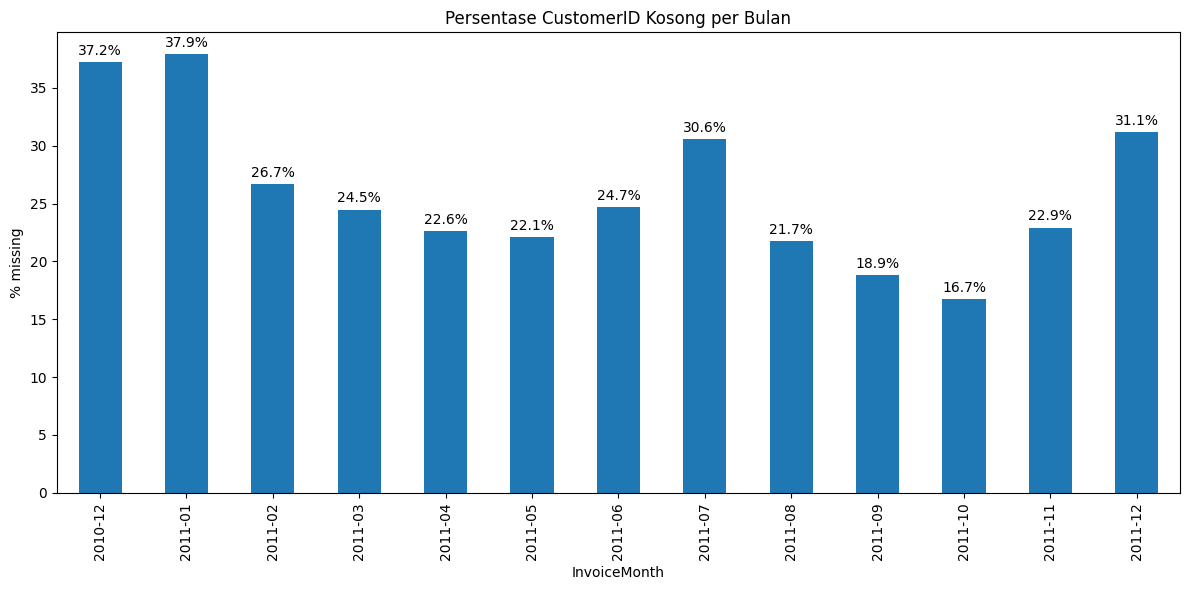

In [30]:
missing_by_month = (
    df.assign(MissingCustomer=df['CustomerID'].isna())
    .groupby('InvoiceMonth')['MissingCustomer'].mean() * 100
)
ax = missing_by_month.plot(kind='bar', figsize=(12, 6), title='Persentase CustomerID Kosong per Bulan')
plt.ylabel('% missing')
plt.bar_label(ax.containers[0], fmt='%.1f%%', padding=3)
plt.tight_layout()
plt.show()

### 1. Ringkasan Masalah Kualitas Data 

Dari total **536.641 baris transaksi**, masalah kualitas data terbesar ada pada kolom **CustomerID**, dengan **135.037 baris (25,16%)** data hilang. Kategori masalah lain relatif kecil dan masih terkendali:

| Kategori Masalah | Jumlah Baris | Persentase |
|---|---|---|
| Missing CustomerID | 135.037 | 25,16% |
| Cancellation/Adjustment | 9.254 | 1,72% |
| Non-product entry | 2.728 | 0,51% |
| Missing Description | 1.454 | 0,27% |

### 2. Missing CustomerID Berdasarkan Negara

Secara **jumlah absolut**, mayoritas data CustomerID yang hilang berasal dari **United Kingdom**, yaitu 133.572 baris (27,24% dari seluruh transaksi UK).

Namun jika diurutkan berdasarkan **persentase per negara**, urutannya berbeda — negara dengan proporsi transaksi tanpa CustomerID tertinggi justru bukan UK:

1. **Hong Kong** — 100% (284 dari 284 transaksi)
2. **Unspecified** (negara tidak terdaftar) — 45,48%
3. **United Kingdom** — 27,24%
4. **Israel** — 15,99%
5. **Bahrain** — 10,53%
6. **EIRE** — 8,66%
7. **Switzerland** — 5,87%
8. **Portugal** — 2,58%
9. **France** — 0,77%

Total ada **9 negara** yang memiliki nilai kosong pada CustomerID.

### 3. Tren Bulanan Missing CustomerID

Persentase CustomerID kosong tertinggi terjadi pada **musim liburan/akhir tahun**:
- **Januari 2011** — 37,9% (puncak tertinggi / peak)
- **Desember 2010** — 37,2%
- **Desember 2011** — 31,1%

Ini mengindikasikan tingginya transaksi **guest checkout** (pembelian tanpa login/registrasi akun) saat volume penjualan musim liburan sedang tinggi.

Sebaliknya, tingkat missing paling rendah terjadi di:
- **Oktober 2011** — 16,7% (terendah)
- **September 2011** — 18,9%

## 5.2 Customer Analysis

### RFM Analysis

In [31]:
df_product['Revenue'] = df_product['Quantity'] * df_product['UnitPrice']
df_cust = df[(df['InvoiceType'] == 'Normal') & df['CustomerID'].notna()].copy()
snapshot_date = df_cust['InvoiceDate'].max() + pd.Timedelta(days=1)

reference_date = df_product['InvoiceDate'].max() + pd.Timedelta(days=1)

# RFM Analysis for customer segmentation
rfm = df_product.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (reference_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum')
).reset_index()

print(rfm.head(10))
print(rfm.describe())

  CustomerID  Recency  Frequency  Monetary
0    12346.0      326          1  77183.60
1    12347.0        2          7   4310.00
2    12348.0       75          4   1437.24
3    12349.0       19          1   1457.55
4    12350.0      310          1    294.40
5    12352.0       36          7   1385.74
6    12353.0      204          1     89.00
7    12354.0      232          1   1079.40
8    12355.0      214          1    459.40
9    12356.0       23          3   2487.43
           Recency    Frequency       Monetary
count  4336.000000  4336.000000    4336.000000
mean     92.690498     4.247924    2016.623303
std     100.202189     7.647368    8918.415878
min       1.000000     1.000000       0.000000
25%      18.000000     1.000000     304.247500
50%      51.000000     2.000000     662.565000
75%     143.000000     5.000000    1631.327500
max     374.000000   206.000000  279138.020000


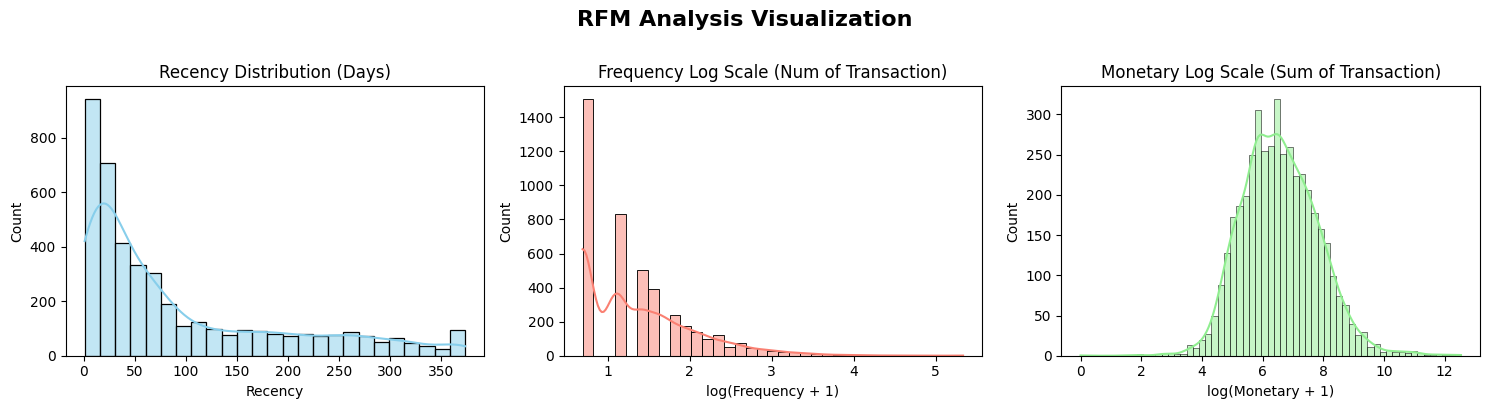

In [32]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

fig.suptitle('RFM Analysis Visualization', fontsize=16, fontweight='bold', y=1.01)

# Recency
sns.histplot(rfm['Recency'], kde=True, ax=ax[0], color='skyblue')
ax[0].set_title('Recency Distribution (Days)')

# Frequency
sns.histplot(np.log1p(rfm['Frequency']), kde=True, ax=ax[1], color='salmon')
ax[1].set_title('Frequency Log Scale (Num of Transaction)')
ax[1].set_xlabel('log(Frequency + 1)')

# Monetary
sns.histplot(np.log1p(rfm['Monetary']), kde=True, ax=ax[2], color='lightgreen')
ax[2].set_title('Monetary Log Scale (Sum of Transaction)')
ax[2].set_xlabel('log(Monetary + 1)')

plt.tight_layout()
plt.show()

### Customer Value & Behavior

Top 20% customers donate 74.6% from total revenue


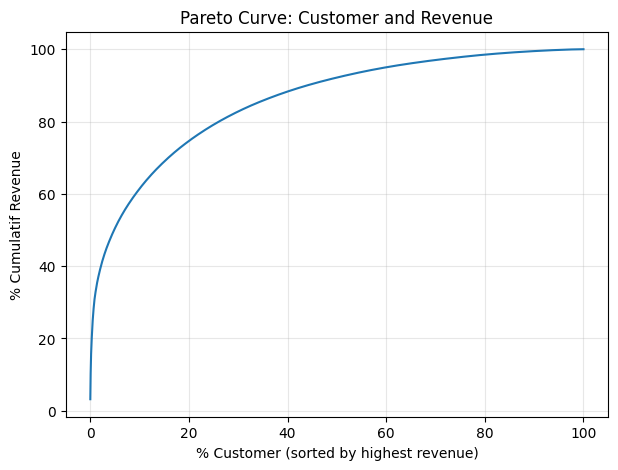

In [33]:
rfm_sorted = rfm.sort_values('Monetary', ascending=False)
rfm_sorted['cum_revenue_pct'] = rfm_sorted['Monetary'].cumsum() / rfm_sorted['Monetary'].sum() * 100
rfm_sorted['cum_customer_pct'] = (np.arange(1, len(rfm_sorted)+1) / len(rfm_sorted)) * 100

pct_20 = rfm_sorted[rfm_sorted['cum_customer_pct'] <= 20]['cum_revenue_pct'].max()
print(f'Top 20% customers donate {pct_20:.1f}% from total revenue')

plt.figure(figsize=(7,5))
plt.plot(rfm_sorted['cum_customer_pct'].values, rfm_sorted['cum_revenue_pct'].values)
plt.xlabel('% Customer (sorted by highest revenue)')
plt.ylabel('% Cumulatif Revenue')
plt.title('Pareto Curve: Customer and Revenue')
plt.grid(True, alpha=0.3)
plt.show()

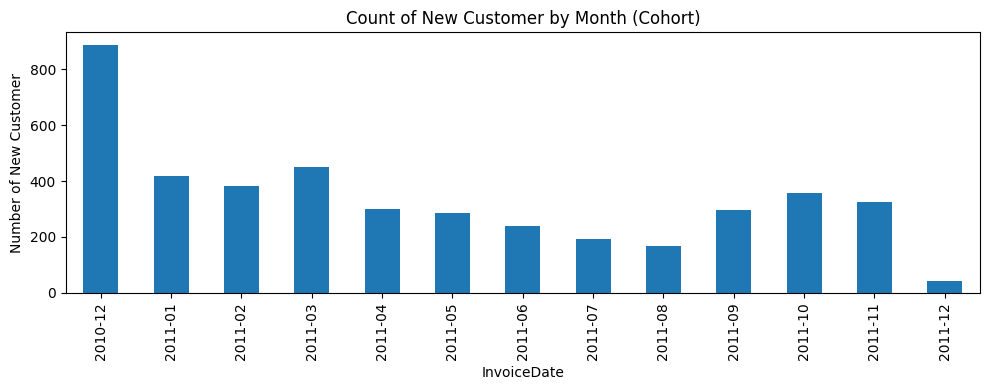

In [34]:
first_purchase = df_cust.groupby('CustomerID')['InvoiceDate'].min().dt.to_period('M')
cohort_counts = first_purchase.value_counts().sort_index()
cohort_counts.plot(kind='bar', figsize=(10,4), title='Count of New Customer by Month (Cohort)')
plt.ylabel('Number of New Customer')
plt.tight_layout()
plt.show()

In [35]:
repeat_vs_onetime = (rfm['Frequency'] > 1).value_counts(normalize=True) * 100
repeat_vs_onetime.index = ['One-time buyer', 'Repeat buyer']
print(repeat_vs_onetime.round(2))

One-time buyer    65.27
Repeat buyer      34.73
Name: proportion, dtype: float64


In [36]:
top_by_revenue = rfm.sort_values('Monetary', ascending=False).head(5)
top_by_frequency = rfm.sort_values('Frequency', ascending=False).head(5)
print('Top 5 by Monetary:'); print(top_by_revenue)
print()
print('Top 5 by Frequency:'); print(top_by_frequency)

Top 5 by Monetary:
     CustomerID  Recency  Frequency   Monetary
1690    14646.0        2         73  279138.02
4199    18102.0        1         60  259657.30
3727    17450.0        8         46  194390.79
3008    16446.0        1          2  168472.50
1880    14911.0        1        199  140336.83

Top 5 by Frequency:
     CustomerID  Recency  Frequency   Monetary
326     12748.0        1        206   31650.78
1880    14911.0        1        199  140336.83
4009    17841.0        2        124   40495.99
562     13089.0        3         97   58762.08
1662    14606.0        1         91   11941.15


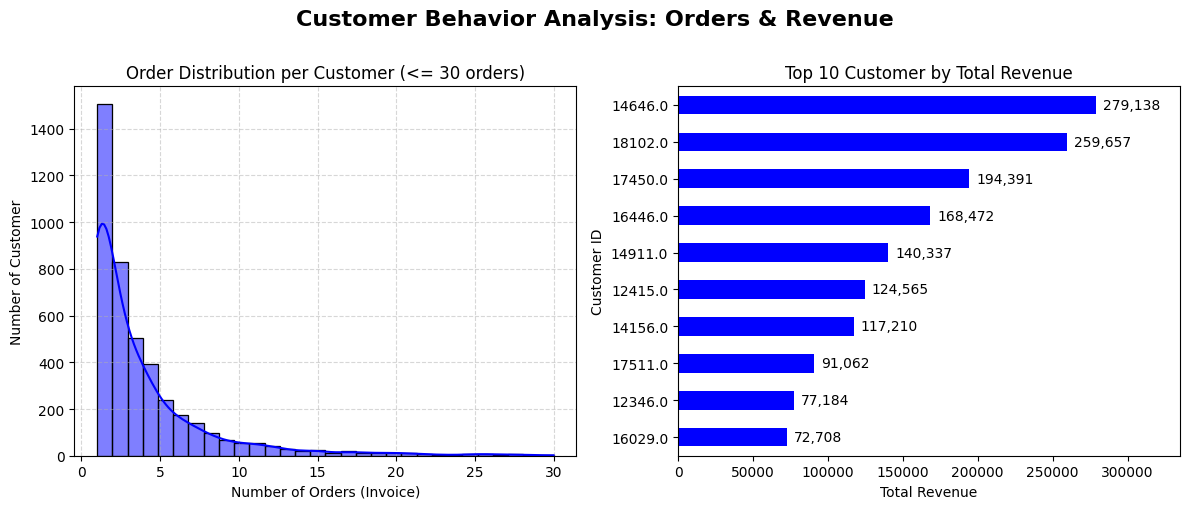

In [37]:
order_per_customer = df_product.groupby('CustomerID')['InvoiceNo'].nunique()
revenue_per_customer = df_product.groupby('CustomerID')['Revenue'].sum().sort_values(ascending=False)

top_10_revenue = revenue_per_customer.head(10)
top_10_revenue.index = top_10_revenue.index.astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Customer Behavior Analysis: Orders & Revenue', fontsize=16, fontweight='bold', y=1.01)

q99_order = order_per_customer.quantile(0.99)
filtered_order = order_per_customer[order_per_customer <= q99_order]

sns.histplot(filtered_order, bins=30, kde=True, ax=axes[0], color='blue')
axes[0].set_title(f'Order Distribution per Customer (<= {int(q99_order)} orders)', fontsize=12)
axes[0].set_xlabel('Number of Orders (Invoice)')
axes[0].set_ylabel('Number of Customer')
axes[0].grid(True, linestyle='--', alpha=0.5)

top_10_revenue.plot(kind='barh', ax=axes[1], color='blue')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Customer by Total Revenue', fontsize = 12)
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Customer ID')
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding = 5)
axes[1].set_xlim(0, top_10_revenue.max() * 1.2)

plt.tight_layout()
plt.show()

### RFM Segmentation & Churn

In [38]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 5, labels=[1,2,3,4,5])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)
rfm[['RFM_score']].head()

,RFM_score
0,115
1,555
2,244
3,414
4,112


In [39]:
def segmentation(customer):
    if customer['R_score'] in [4, 5] and customer['F_score'] in [4, 5] and customer['M_score'] in [4, 5]:
        return 'Champions'
    elif customer['R_score'] in [1, 2] and customer['F_score'] in [1, 2]:
        return 'Churned'
    elif customer['F_score'] in [4, 5]:
        return 'Loyal'
    elif customer['R_score'] in [4, 5]:
        return 'New'
    else:
        return 'Others'

rfm['Segment'] = rfm.apply(segmentation, axis = 1)
print(rfm['Segment'].value_counts())

rfm['Churn'] = np.where(rfm['Segment'] == "Churned", "Churn", "No-Churn")
rfm['Churn'].value_counts()

Segment
Churned      1068
Champions     955
Others        899
Loyal         779
New           635
Name: count, dtype: int64


Churn
No-Churn    3268
Churn       1068
Name: count, dtype: int64

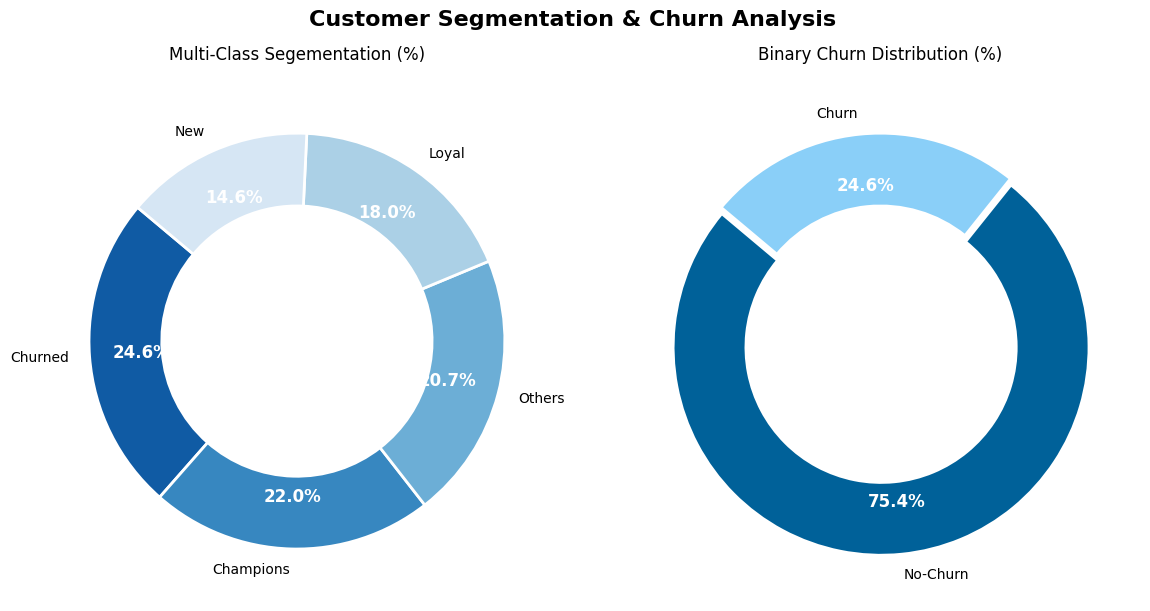

In [40]:
segment_counts = rfm['Segment'].value_counts()
churn_counts = rfm['Churn'].value_counts()

fig, axes = plt.subplots(1, 2, figsize=(12, 6))
fig.suptitle('Customer Segmentation & Churn Analysis', fontsize = 16, fontweight='bold', y = 1.01)

colors_seg = sns.color_palette('Blues_r', n_colors=len(segment_counts))

wedges0, texts0, autotexts0 = axes[0].pie(
    segment_counts,
    labels=segment_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=colors_seg,
    pctdistance=0.75,
    wedgeprops = dict(width=0.35, edgecolor='white', linewidth = 2)
)
axes[0].set_title('Multi-Class Segementation (%)', fontsize=12, pad = 15)

for autotext in autotexts0:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

wedges1, texts1, autotexts1 = axes[1].pie(
    churn_counts,
    labels=churn_counts.index,
    autopct='%1.1f%%',
    startangle=140,
    colors=['#006199', '#8ACFF8'],
    explode=(0.03, 0),
    pctdistance=0.75,
    wedgeprops = dict(width=0.35, edgecolor='white', linewidth = 2)
)
axes[1].set_title('Binary Churn Distribution (%)', fontsize=12, pad = 15)

for autotext in autotexts1:
    autotext.set_color('white')
    autotext.set_fontweight('bold')
    autotext.set_fontsize(12)

plt.tight_layout()
plt.show()

### 1. Ringkasan Statistik RFM 

Analisis dilakukan terhadap **4.336 pelanggan (CustomerID Unique Values)**. Statistik deskriptifnya:

| Metrik | Mean | Median | Min | Max |
|---|---|---|---|---|
| Recency (hari) | 92,7 | 50 | 0 | 374 |
| Frequency (transaksi) | 4,25 | 2 | 1 | 206 |
| Monetary | 2.016,62 | 662,57 | 0 | 279.138,02 |

Selisih besar antara **mean dan median** pada ketiga metrik (terutama Frequency dan Monetary) mengindikasikan distribusi yang **sangat right-skewed** — mayoritas pelanggan bertransaksi kecil dan jarang, tetapi ada sebagian kecil pelanggan dengan frekuensi & nilai transaksi ekstrem tinggi yang menarik rata-rata ke atas.

### 2. Distribusi Recency, Frequency, Monetary 

- **Recency**: mayoritas pelanggan baru saja bertransaksi (puncak di 0–50 hari), lalu jumlahnya menurun tajam — menunjukkan sebagian besar pelanggan aktif, namun ada "ekor panjang" pelanggan yang sudah lama tidak bertransaksi (>300 hari).
- **Frequency** (skala log): sebagian besar pelanggan hanya bertransaksi **1 kali**, dan jumlahnya menurun cepat seiring bertambahnya frekuensi — pola khas **power law**, mengonfirmasi banyaknya one-time buyer.
- **Monetary** (skala log): setelah transformasi log, distribusinya mendekati **normal**, artinya secara proporsional (bukan nominal absolut) nilai belanja pelanggan cukup konsisten di sekitar rentang tertentu.

### 3. Prinsip Pareto pada Revenue 

**Top 20% pelanggan menyumbang 74,6% dari total revenue** — mengonfirmasi berlakunya **prinsip Pareto (80/20)** pada basis pelanggan bisnis ini. Ini menunjukkan ketergantungan bisnis yang cukup tinggi terhadap segmen pelanggan kecil namun bernilai besar (high-value customers), sehingga strategi retensi untuk segmen ini menjadi krusial.

### 4. Akuisisi Pelanggan Baru per Bulan 

- **Desember 2010** mencatat jumlah pelanggan baru tertinggi (~890), yang merupakan efek awal periode data (semua pelanggan pertama kali tercatat "baru" di bulan ini).
- Setelah itu, akuisisi pelanggan baru **menurun signifikan** dan relatif stagnan di kisaran 200–450 pelanggan/bulan sepanjang 2011, dengan titik terendah di **Juli–Agustus 2011** (~170–190).
- **Desember 2011** terlihat sangat rendah (~40), kemungkinan karena data periode ini **tidak lengkap** (invoice terpotong sebelum akhir bulan), bukan penurunan akuisisi yang sesungguhnya.

### 5. Proporsi One-time vs Repeat Buyer 

- **One-time buyer: 65,27%**
- **Repeat buyer: 34,73%**

Mayoritas pelanggan **hanya bertransaksi satu kali**, menandakan tantangan besar pada **retensi pelanggan**. Dengan hanya sepertiga pelanggan yang kembali bertransaksi, ada peluang besar untuk strategi *re-engagement* (email marketing, loyalty program, dsb).

### 6. Top Pelanggan Berdasarkan Monetary & Frequency 

**Top 5 by Monetary:**
| CustomerID | Frequency | Monetary |
|---|---|---|
| 14646 | 73 | 279.138 |
| 18102 | 60 | 259.657 |
| 17450 | 46 | 194.391 |
| 16446 | 2 | 168.472 |
| 14911 | 199 | 140.337 |

**Top 5 by Frequency:**
| CustomerID | Frequency | Monetary |
|---|---|---|
| 12748 | 206 | 31.658 |
| 14911 | 199 | 140.337 |
| 17841 | 124 | 40.495 |
| 13089 | 97 | 58.762 |
| 15311 | 91 | 60.632 |

Menarik: **CustomerID 16446** masuk top 5 Monetary hanya dengan **2 transaksi** (nilai rata-rata per transaksi sangat besar, ~84.236) — kemungkinan pembelian dalam jumlah besar/bulk order. Sebaliknya, **CustomerID 12748** paling sering bertransaksi (206 kali) tapi nilai totalnya justru lebih rendah dari beberapa pelanggan lain — mengindikasikan pelanggan dengan pola belanja rutin namun nominal kecil per transaksi.

**CustomerID 14911** konsisten muncul di kedua kategori (top revenue #5 dan top frequency #2) — profil pelanggan paling ideal: **loyal dan bernilai tinggi**.

Distribusi jumlah order per pelanggan juga mengonfirmasi pola Pareto: mayoritas pelanggan hanya melakukan **1–2 order**, sementara segelintir pelanggan (seperti 14646 dan 18102) memberikan kontribusi revenue jauh di atas rata-rata.

### 7. Customer Segmentation 

Dari total **4.336 pelanggan**, distribusi segmentasi berdasarkan RFM adalah sebagai berikut:

| Segment | Jumlah Pelanggan | Persentase |
|---|---|---|
| Churned | 1.068 | 24,6% |
| Champions | 955 | 22,0% |
| Others | 899 | 20,7% |
| Loyal | 779 | 18,0% |
| New | 635 | 14,6% |

**Insight utama:**
- **Champions (22,0%)** adalah segmen kedua terbesar — pelanggan dengan Recency rendah, Frequency & Monetary tinggi. Ini adalah aset paling berharga bagi bisnis dan selaras dengan temuan Pareto sebelumnya (top 20% pelanggan menyumbang 74,6% revenue).
- **Churned (24,6%)** menjadi segmen **terbesar**, menandakan hampir seperempat basis pelanggan sudah "hilang" (Recency sangat tinggi, tidak lagi bertransaksi). Ini konsisten dengan temuan sebelumnya bahwa **65,27% pelanggan adalah one-time buyer** — banyak pelanggan yang datang sekali lalu tidak kembali.
- **Loyal (18,0%)** dan **New (14,6%)** menunjukkan ada basis pelanggan yang sedang berkembang, tetapi masih lebih kecil dibanding pelanggan yang sudah churn.
- **Others (20,7%)** kemungkinan mencakup segmen campuran seperti "At Risk", "Potential Loyalist", atau "Need Attention" yang belum masuk kategori ekstrem manapun.

### 8. Binary Churn Distribution 

Secara sederhana (churn vs no-churn):
- **No-Churn: 75,4%** (3.268 pelanggan)
- **Churn: 24,6%** (1.068 pelanggan)

**Insight:**
Angka churn **24,6%** ini tergolong **cukup tinggi** untuk bisnis retail/e-commerce (benchmark industri biasanya di kisaran 20–30% dianggap wajar, tapi tetap perlu perhatian). Digabungkan dengan temuan bahwa **mayoritas pelanggan adalah one-time buyer**, ini menunjukkan **akar masalah utama ada di tahap retensi setelah pembelian pertama**, bukan di akuisisi — karena akuisisi pelanggan baru (Gambar 4 sebelumnya) sebenarnya cukup stabil.

**Rekomendasi actionable:**
- **Champions & Loyal (40% total)** → pertahankan dengan program loyalitas/reward eksklusif.
- **Churned (24,6%)** → kampanye *win-back* (diskon khusus, email re-engagement) karena mereka sebelumnya pernah bertransaksi (bukan pelanggan yang tidak dikenal).
- **New (14,6%)** → fokus onboarding & pembelian kedua, karena data menunjukkan mayoritas pelanggan berhenti setelah transaksi pertama — momen kritis untuk konversi ke repeat buyer.

## 5.3 Product Analysis

### Top Products

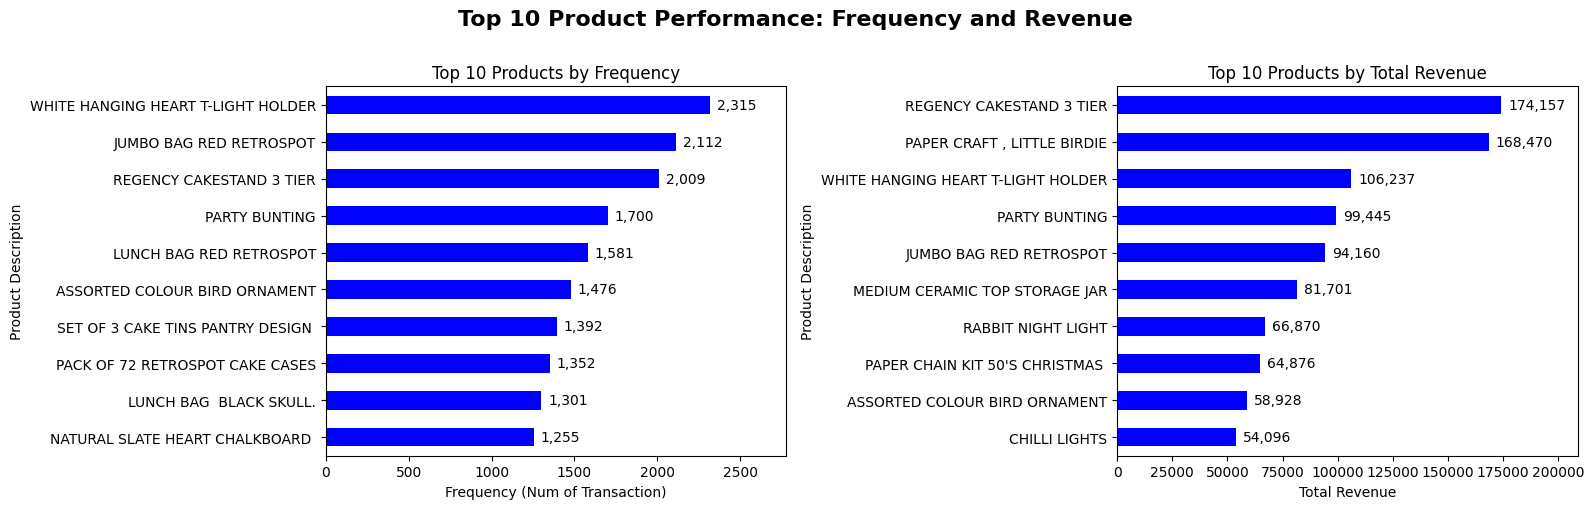

In [41]:
top_freq = df_product['Description'].value_counts().head(10)
top_revenue = df_product.groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

fig.suptitle('Top 10 Product Performance: Frequency and Revenue', fontsize=16, fontweight='bold', y=1.01)

top_freq.plot(kind='barh', ax=axes[0], color="blue")
axes[0].invert_yaxis()
axes[0].set_title('Top 10 Products by Frequency')
axes[0].set_xlabel('Frequency (Num of Transaction)')
axes[0].set_ylabel('Product Description')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', padding = 5)
axes[0].set_xlim(0, top_freq.max() * 1.2)


top_revenue.plot(kind='barh', ax=axes[1], color='blue')
axes[1].invert_yaxis()
axes[1].set_title('Top 10 Products by Total Revenue', fontsize=12)
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Product Description')
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding = 5)
axes[1].set_xlim(0, top_revenue.max() * 1.2)

plt.tight_layout()
plt.show()

### Revenue Concentration (Pareto)

In [42]:
df_prod = df[(df['InvoiceType']=='Normal') & df['IsProduct'] & df['HasDescription']]
revenue_by_product = df_prod.groupby('Description')['Revenue'].sum().sort_values(ascending=False)

cum_pct = revenue_by_product.cumsum() / revenue_by_product.sum() * 100
n_products_80pct = (cum_pct <= 80).sum()
print(f'Jumlah produk unik: {len(revenue_by_product)}')
print(f'Jumlah produk yang menyumbang 80% revenue: {n_products_80pct} '
      f'({n_products_80pct/len(revenue_by_product)*100:.1f}% dari total produk)')

Jumlah produk unik: 4201
Jumlah produk yang menyumbang 80% revenue: 850 (20.2% dari total produk)


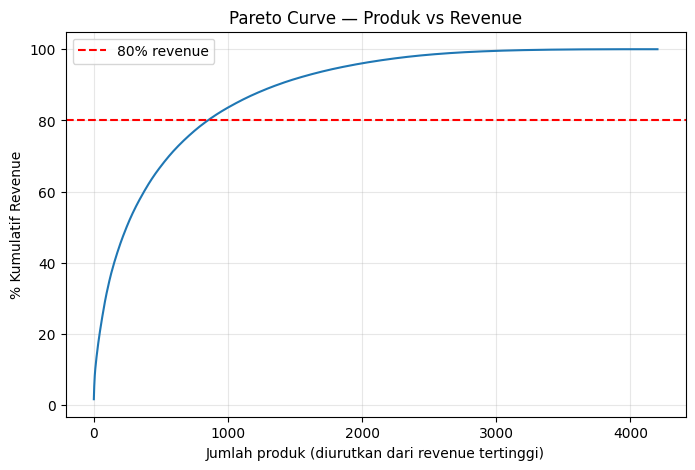

In [43]:
plt.figure(figsize=(8,5))
plt.plot(range(1, len(cum_pct)+1), cum_pct.values)
plt.axhline(80, color='red', linestyle='--', label='80% revenue')
plt.xlabel('Jumlah produk (diurutkan dari revenue tertinggi)')
plt.ylabel('% Kumulatif Revenue')
plt.title('Pareto Curve — Produk vs Revenue')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Price Variation & Keyword Category

In [44]:
price_variation = (
    df_prod.groupby('Description')['UnitPrice']
    .agg(['mean', 'std', 'min', 'max', 'count'])
    .query('count >= 10')
    .sort_values('std', ascending=False)
    .head(10)
)
price_variation

,mean,std,min,max,count
Description,,,,,
VINTAGE BLUE KITCHEN CABINET,146.750000,66.039761,50.00,295.00,20
VINTAGE RED KITCHEN CABINET,143.421053,62.136568,50.00,295.00,38
LOVE SEAT ANTIQUE WHITE METAL,114.024390,48.621234,85.00,195.00,41
CINDERELLA CHANDELIER,45.487391,17.964517,10.00,99.96,23
SWEETHEART CREAM STEEL TABLE RECT,23.760000,17.459613,19.95,99.96,21
STEEL SWEETHEART ROUND TABLE CREAM,18.561667,12.236176,14.95,58.29,24
MEDINA STAMPED METAL STOOL,39.869500,11.956783,5.00,78.29,20
SET/4 WHITE RETRO STORAGE CUBES,45.232258,11.367487,34.95,76.55,155
CABIN BAG VINTAGE RETROSPOT,22.484118,10.482038,12.75,58.29,68


In [45]:
keywords = ['CHRISTMAS', 'BAG', 'MUG', 'BOX', 'LIGHT', 'CARD', 'BOTTLE', 'CANDLE']

def categorize(desc):
    desc = str(desc).upper()
    for kw in keywords:
        if kw in desc:
            return kw
    return 'OTHER'

df_prod = df_prod.copy()
df_prod['Category'] = df_prod['Description'].apply(categorize)
category_revenue = df_prod.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
category_revenue

Category
OTHER        6824967.271
BAG          1068851.050
LIGHT         632689.290
BOX           533930.630
CHRISTMAS     460079.660
BOTTLE        311435.870
CARD          162554.380
MUG           131017.370
CANDLE        129598.160
Name: Revenue, dtype: float64

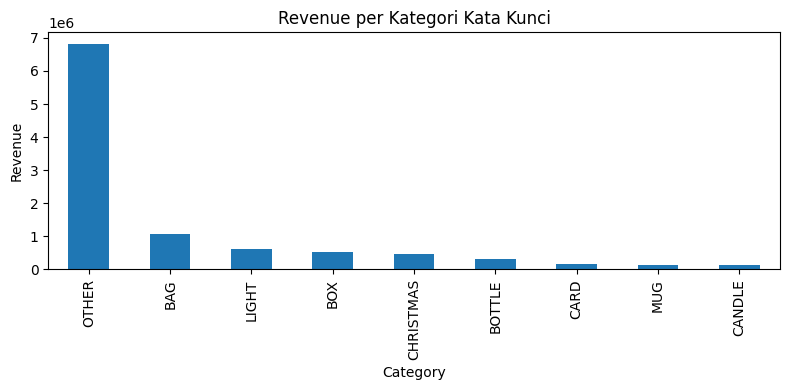

In [46]:
category_revenue.plot(kind='bar', figsize=(8,4), title='Revenue per Kategori Kata Kunci')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

### 1. Top Produk Berdasarkan Frequency & Revenue (Gambar 1)

**Top 3 by Frequency (paling sering dibeli):**
1. White Hanging Heart T-Light Holder — 2.315 transaksi
2. Jumbo Bag Red Retrospot — 2.112 transaksi
3. Regency Cakestand 3 Tier — 2.009 transaksi

**Top 3 by Revenue (paling menguntungkan):**
1. Regency Cakestand 3 Tier — 174.157
2. Paper Craft, Little Birdie — 168.470
3. White Hanging Heart T-Light Holder — 106.237

**Insight:**
- **Regency Cakestand 3 Tier** dan **White Hanging Heart T-Light Holder** masuk top 3 di kedua kategori — ini adalah produk **"star product"**: laris sekaligus menguntungkan, layak jadi prioritas stok dan promosi utama.
- **Paper Craft, Little Birdie** menarik: peringkat revenue #2 (168.470) tapi **tidak masuk** top 10 by frequency. Artinya produk ini punya **average order value tinggi** — kemungkinan dibeli dalam jumlah besar per transaksi (bulk buyer/reseller), bukan pembelian eceran yang sering.
- Sebaliknya, produk seperti **Lunch Bag Red Retrospot** dan **Pack of 72 Retrospot Cake Cases** sering dibeli (frequency tinggi) tapi tidak masuk top 10 revenue — mengindikasikan harga satuan rendah (produk volume, bukan margin tinggi).

### 2. Prinsip Pareto pada Produk (Gambar 2)

Dari **4.201 produk unik**, hanya **850 produk (20,2%)** yang menyumbang **80% dari total revenue**.

**Insight:**
Ini kembali mengonfirmasi **pola Pareto** yang konsisten di seluruh analisis (pelanggan maupun produk). Meskipun rasionya (20,2% : 80%) sedikit lebih longgar dibanding aturan 80/20 klasik, tetap menunjukkan **konsentrasi revenue yang tinggi pada sebagian kecil produk**. Implikasinya:
- Fokuskan manajemen inventori & strategi marketing pada ~850 produk "penggerak revenue" ini.
- Sisa **~3.351 produk (79,8%)** hanya menyumbang 20% revenue — kandidat untuk evaluasi (discontinue, bundling, atau clearance) guna efisiensi biaya penyimpanan/operasional.

### 3. Variasi Harga per Produk (Gambar 3)

Beberapa produk unggulan menunjukkan **variasi harga yang cukup besar** antara min dan max, misalnya:
- **Vintage Blue Kitchen Cabinet**: harga berkisar 50–295 (rata-rata 146,75, std 66,04)
- **Vintage Red Kitchen Cabinet**: 50–295 (rata-rata 143,42)
- **Love Seat Antique White Metal**: 85–195 (rata-rata 114,02)

**Insight:**
Standar deviasi yang relatif besar dibanding mean (terutama produk kitchen cabinet & Cinderella Chandelier) mengindikasikan **inkonsistensi harga** — bisa jadi karena diskon, perubahan harga dari waktu ke waktu, atau bundling dalam jumlah berbeda. Produk seperti **Carriage** dan **Set/4 White Retro Storage Cubes** punya std lebih rendah relatif terhadap mean, menandakan harga yang **lebih stabil/konsisten**.

### 4. Revenue per Kategori Kata Kunci (Gambar 4 & 5)

| Kategori | Revenue |
|---|---|
| Other | 6.824.967 |
| Bag | 1.068.851 |
| Light | 632.689 |
| Box | 533.930 |
| Christmas | 460.080 |
| Bottle | 311.435 |
| Card | 162.554 |
| Mug | 131.017 |
| Candle | 129.598 |

**Insight:**
- Kategori **"Other"** mendominasi (~72% dari revenue yang ditampilkan) — ini menunjukkan bahwa klasifikasi kata kunci saat ini **belum menangkap mayoritas produk** ke dalam kategori spesifik. Sebaiknya kategori kata kunci diperluas/diperinci lagi agar analisis kategori lebih bermakna (saat ini insight kategori jadi kurang tajam karena "Other" terlalu besar).
- Di luar "Other", kategori **Bag** adalah kontributor revenue terbesar (1.068.851), jauh di atas kategori lain — sejalan dengan temuan Jumbo Bag Red Retrospot yang masuk top produk.
- Kategori **Christmas** (460.080) cukup signifikan meskipun sifatnya musiman — relevan dengan temuan sebelumnya bahwa Desember adalah bulan dengan transaksi tertinggi.
- Kategori **Light, Box, Bottle, Card, Mug, Candle** menunjukkan diversifikasi produk **home decor/gift items** sebagai inti bisnis ini.

## 5.4 Time Analysis

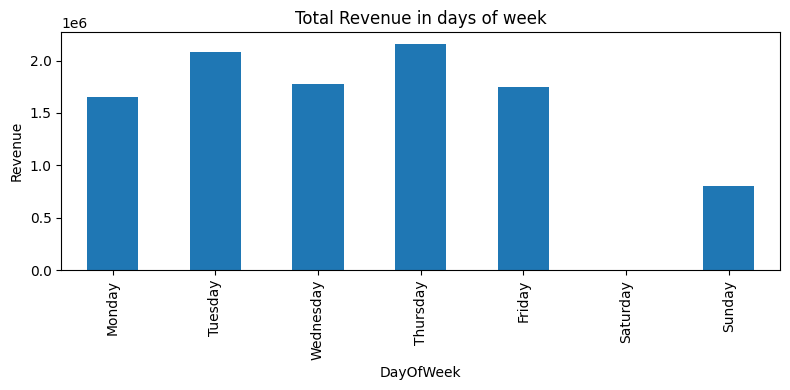

In [47]:
revenue_by_day = (
    df[df['InvoiceType']=='Normal']
    .groupby('DayOfWeek')['Revenue'].sum()
    .reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday'])
)
revenue_by_day.plot(kind='bar', figsize=(8,4), title='Total Revenue in days of week')
plt.ylabel('Revenue')
plt.tight_layout()
plt.show()

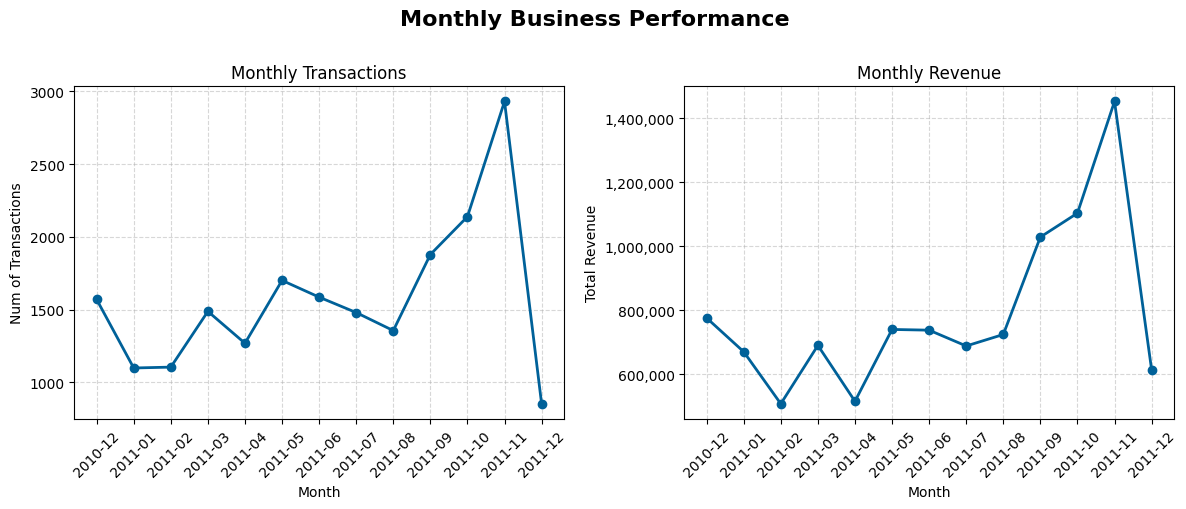

In [48]:
monthly_summary = df_product.groupby(df_product['InvoiceDate'].dt.to_period('M')).agg(
    Num_Transactions = ('InvoiceNo', 'nunique'),
    Total_Revenue = ('Revenue', 'sum')
).reset_index()

monthly_summary['InvoiceMonth'] = monthly_summary['InvoiceDate'].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Monthly Business Performance', fontsize=16, fontweight='bold', y=1.01)

axes[0].plot(monthly_summary['InvoiceMonth'], monthly_summary['Num_Transactions'], marker='o', color='#006199', linewidth=2, markersize=6)
axes[0].set_title('Monthly Transactions', fontsize=12)
axes[0].set_xlabel('Month')
axes[0].set_ylabel('Num of Transactions')
axes[0].tick_params(axis='x', rotation=45)
axes[0].grid(True, linestyle='--', alpha=0.5)

axes[1].plot(monthly_summary['InvoiceMonth'], monthly_summary['Total_Revenue'], marker='o', color='#006199', linewidth=2, markersize=6)
axes[1].set_title('Monthly Revenue', fontsize=12)
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Total Revenue')
axes[1].tick_params(axis='x', rotation=45)
axes[1].grid(True, linestyle='--', alpha=0.5)

axes[1].yaxis.set_major_formatter(ticker.StrMethodFormatter('{x:,.0f}'))

plt.tight_layout()
plt.show()

### 1. Revenue Berdasarkan Hari dalam Seminggu

| Hari | Revenue (approx) |
|---|---|
| Monday | ~1,78 juta |
| Tuesday | ~2,18 juta (tertinggi) |
| Wednesday | ~1,85 juta |
| Thursday | ~2,20 juta (tertinggi) |
| Friday | ~1,83 juta |
| Saturday | 0 |
| Sunday | ~0,80 juta (terendah dari hari aktif) |

**Insight:**
- **Saturday tercatat 0 revenue** — ini kemungkinan besar bukan berarti tidak ada transaksi di hari Sabtu secara bisnis, melainkan toko **memang tutup/tidak beroperasi** pada hari Sabtu (wajar untuk bisnis wholesale B2B seperti ini). Perlu dikonfirmasi ke data mentah agar tidak disalahartikan sebagai anomali.
- **Selasa dan Kamis** adalah hari dengan revenue tertinggi — jika ini bisnis wholesale, kemungkinan pelanggan (retailer) menempatkan order besar di pertengahan minggu untuk restock sebelum akhir pekan.
- **Minggu** memiliki revenue jauh lebih rendah (~0,80 juta) dibanding hari kerja lain — mengindikasikan transaksi weekend jauh lebih sepi, konsisten dengan karakter bisnis B2B/wholesale yang beroperasi mengikuti jam kerja normal.

**Rekomendasi:** Jadwalkan promosi, email campaign, atau penawaran khusus pada **Senin/Selasa pagi** agar menangkap momentum order mingguan pelanggan.

### 2. Performa Bisnis Bulanan

**Pola Transaksi & Revenue:**
- Terjadi **penurunan awal** dari Desember 2010 ke Januari–Februari 2011 (transaksi turun dari ~1.580 ke ~1.100), kemungkinan efek musiman pasca-liburan (post-holiday slump).
- Tren **relatif stabil** di kisaran 1.300–1.700 transaksi selama Maret–Agustus 2011.
- **Lonjakan tajam** mulai September hingga puncaknya di **November 2011** — jumlah transaksi mencapai hampir **2.950** dan revenue mencapai **~1,46 juta**, tertinggi sepanjang periode data.
- **Desember 2011 anjlok drastis** (transaksi hanya ~850, revenue ~620 ribu) — namun ini **kemungkinan besar karena data terpotong** (invoice tidak mencakup bulan penuh), bukan penurunan bisnis riil. Konsisten dengan temuan sebelumnya di analisis akuisisi pelanggan baru (Gambar 4 di insight sebelumnya) yang juga menunjukkan anomali serupa di Desember 2011.

**Insight kunci:**
- **November 2011** adalah puncak performa bisnis — kemungkinan terkait persiapan stok pelanggan (retailer) menjelang musim belanja Natal/akhir tahun, sejalan dengan sifat bisnis wholesale gift & home decor.
- Pola *transactions* dan *revenue* bergerak **searah (korelasi kuat)** — kenaikan jumlah order diikuti kenaikan revenue secara proporsional, menandakan tidak ada perubahan signifikan pada average order value dari bulan ke bulan.
- Perlu tindak lanjut: **klarifikasi rentang data Desember 2011** untuk memastikan apakah data lengkap satu bulan penuh atau memang terpotong, agar tidak salah menyimpulkan penurunan performa di akhir periode.

## 5.5 Geography Analysis

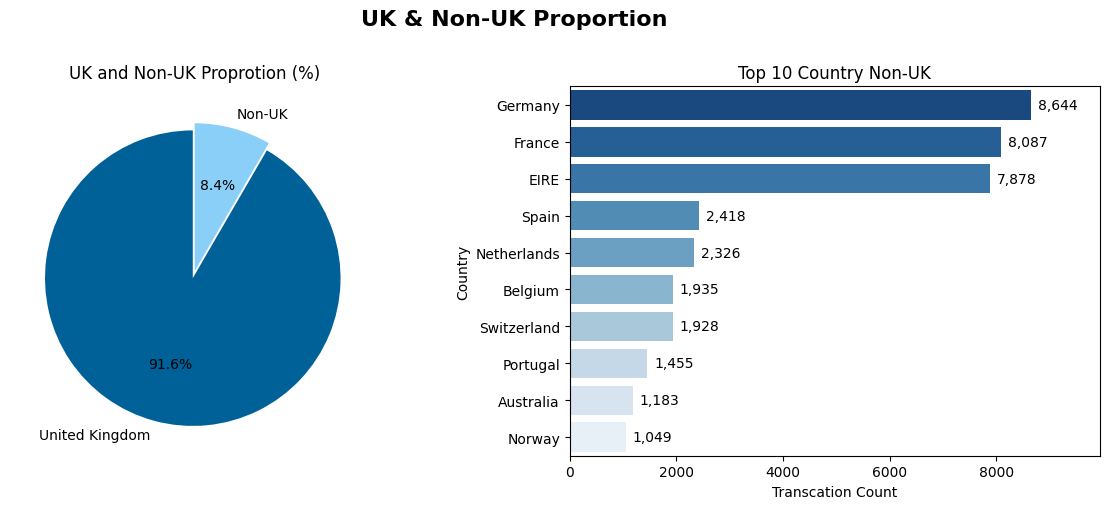

In [49]:
country_df = df_product['Country'].value_counts()

country_s = country_df['count'] if isinstance(country_df, pd.DataFrame) else country_df

uk_n_rest = pd.Series({
    "United Kingdom": country_s['United Kingdom'],
    "Non-UK": country_s.drop('United Kingdom').sum()
})

top_non_uk = country_s.drop('United Kingdom').head(10)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

fig.suptitle('UK & Non-UK Proportion', fontsize=16, fontweight='bold', y=1.01)

axes[0].pie(uk_n_rest, labels=uk_n_rest.index, autopct='%1.1f%%',
         colors=['#006199', '#8ACFF8'], startangle=90, explode=(0.05, 0))
axes[0].set_title("UK and Non-UK Proprotion (%)")

ax = sns.barplot(x=top_non_uk.values, y=top_non_uk.index, ax=axes[1], palette='Blues_r')

for p in ax.patches:
    width = p.get_width()
    ax.annotate(f'{int(width):,}', (width, p.get_y() + p.get_height() / 2.),
               ha = 'left', va='center', xytext=(5, 0), textcoords='offset points')

axes[1].set_title("Top 10 Country Non-UK")
axes[1].set_xlabel("Transcation Count")
axes[1].set_xlim(0, max(top_non_uk.values) * 1.15)

# plt.title("Country Distribution")
plt.tight_layout()
plt.show()

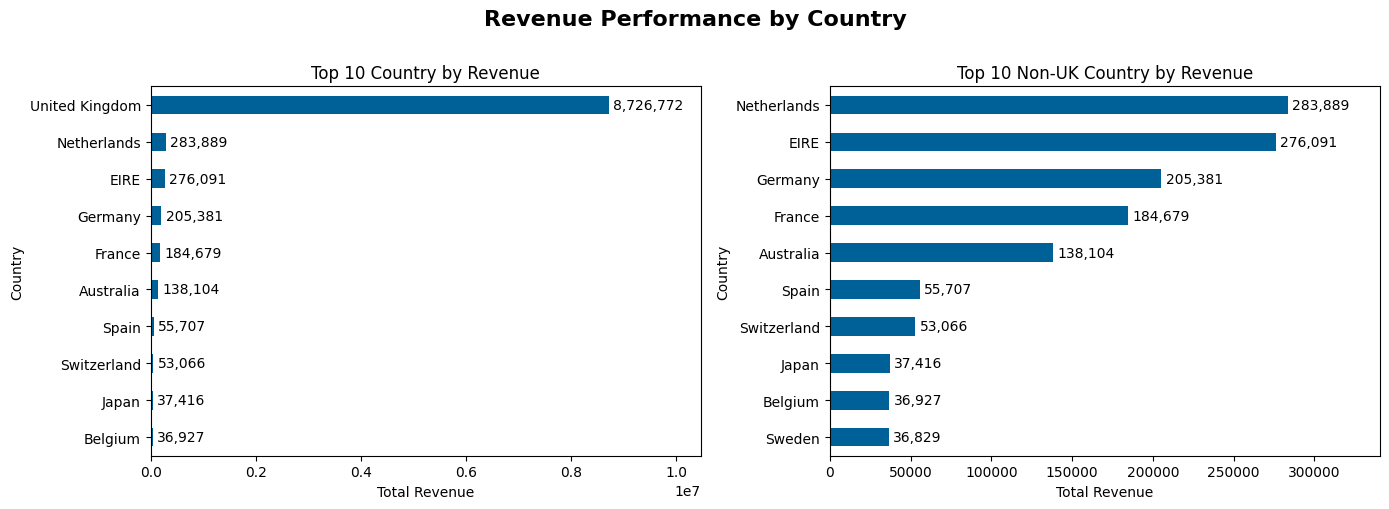

In [50]:
revenue_by_country = df_product.groupby('Country')['Revenue'].sum().sort_values(ascending=False)

top_all = revenue_by_country.head(10)
top_non_uk = revenue_by_country.drop(['United Kingdom'], errors='ignore').head(10)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

fig.suptitle('Revenue Performance by Country', fontsize=16, fontweight='bold', y=1.01)

top_all.plot(kind='barh', ax=axes[0], color="#006199")

axes[0].invert_yaxis()
axes[0].set_title('Top 10 Country by Revenue', fontsize=12)
axes[0].set_xlabel('Total Revenue')
axes[0].set_ylabel('Country')
axes[0].bar_label(axes[0].containers[0], fmt='{:,.0f}', padding=3)
axes[0].set_xlim(0, top_all.max() * 1.2)

top_non_uk.plot(kind='barh',ax=axes[1], color="#006199")

axes[1].invert_yaxis()
axes[1].set_title('Top 10 Non-UK Country by Revenue', fontsize=12)
axes[1].set_xlabel('Total Revenue')
axes[1].set_ylabel('Country')
axes[1].bar_label(axes[1].containers[0], fmt='{:,.0f}', padding=3)
axes[1].set_xlim(0, top_non_uk.max() * 1.2)

plt.tight_layout()
plt.show()

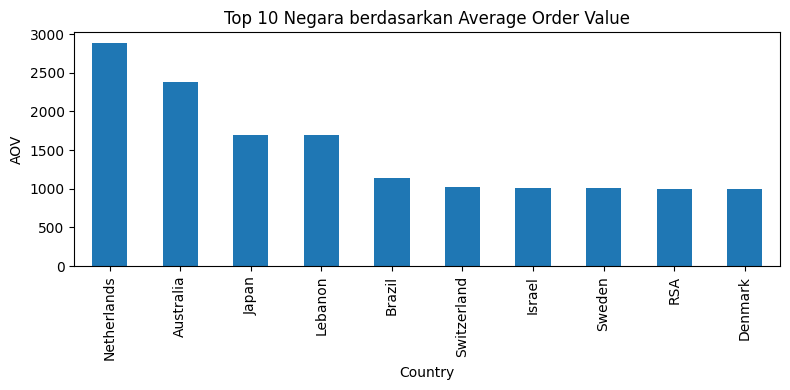

In [51]:
aov_country = (
    df[df['InvoiceType']=='Normal']
    .groupby(['Country', 'InvoiceNo'])['Revenue'].sum()
    .groupby('Country').mean()
    .sort_values(ascending=False)
)
aov_country.head(10).plot(kind='bar', figsize=(8,4), title='Top 10 Negara berdasarkan Average Order Value')
plt.ylabel('AOV')
plt.tight_layout()
plt.show()

In [52]:
df_prod_geo = df[(df['InvoiceType']=='Normal') & df['IsProduct'] & df['HasDescription']].copy()
df_prod_geo['Region'] = np.where(df_prod_geo['Country'] == 'United Kingdom', 'UK', 'Non-UK')

top_uk = df_prod_geo[df_prod_geo['Region']=='UK'].groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5)
top_nonuk = df_prod_geo[df_prod_geo['Region']=='Non-UK'].groupby('Description')['Revenue'].sum().sort_values(ascending=False).head(5)

print('Top 5 Produk (UK):'); print(top_uk)
print()
print('Top 5 Produk (Non-UK):'); print(top_nonuk)

Top 5 Produk (UK):
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              141996.09
WHITE HANGING HEART T-LIGHT HOLDER    100444.62
PARTY BUNTING                          93599.43
JUMBO BAG RED RETROSPOT                86291.10
Name: Revenue, dtype: float64

Top 5 Produk (Non-UK):
Description
REGENCY CAKESTAND 3 TIER               32160.45
RABBIT NIGHT LIGHT                     28877.04
ROUND SNACK BOXES SET OF4 WOODLAND     18469.15
SPACEBOY LUNCH BOX                     14468.85
DOLLY GIRL LUNCH BOX                   12595.35
Name: Revenue, dtype: float64


In [53]:
cust_per_country = df[df['CustomerID'].notna()].groupby('Country')['CustomerID'].nunique()
txn_per_country = df.groupby('Country')['InvoiceNo'].nunique()

ratio = (txn_per_country / cust_per_country).sort_values(ascending=False)
ratio.head(10)  # rata-rata jumlah invoice per pelanggan, per negara

Country
EIRE                  120.000000
Netherlands            11.222222
Singapore              10.000000
Australia               7.666667
Iceland                 7.000000
Germany                 6.347368
United Kingdom          5.947848
Sweden                  5.750000
France                  5.298851
European Community      5.000000
dtype: float64

### 1. Proporsi UK vs Non-UK 

Transaksi didominasi oleh **United Kingdom (91,6%)**, sementara **Non-UK hanya 8,4%** dari total transaksi. Ini mengonfirmasi bahwa bisnis ini pada dasarnya adalah **pemain domestik UK** dengan ekspansi internasional yang masih terbatas.

Di antara negara Non-UK, **Jerman (8.644 transaksi)**, **Prancis (8.087)**, dan **EIRE/Irlandia (7.878)** menjadi tiga pasar terbesar — jauh di atas negara Non-UK lainnya seperti Spanyol (2.418) dan Belanda (2.326). Ketiga negara ini kemungkinan menjadi target utama jika ada rencana ekspansi lebih lanjut di Eropa.

### 2. Revenue per Negara 

Secara nominal, **UK menyumbang 8.726.772** dari total revenue — dominasi yang jauh lebih ekstrem dibanding proporsi transaksinya (91,6%), menandakan **average order value UK juga lebih tinggi** secara agregat dibanding gabungan negara lain.

Di luar UK, **Belanda (283.889)** dan **EIRE (276.091)** menjadi kontributor revenue Non-UK terbesar, disusul **Jerman (205.381)** dan **Prancis (184.679)**.

Menariknya, meski Jerman dan Prancis memiliki **jumlah transaksi** lebih tinggi dibanding Belanda dan EIRE, **revenue** mereka justru lebih rendah — mengindikasikan **nilai transaksi rata-rata (AOV)** Jerman dan Prancis lebih kecil per order dibanding Belanda/EIRE. Pola ini konsisten dengan temuan pada Gambar 3.

### 3. Average Order Value per Negara 

Ranking AOV tertinggi:
1. **Singapore** (~3.050)
2. **Netherlands** (~3.000)
3. **Australia** (~2.420)
4. **Japan** (~1.960)
5. **Lebanon** (~1.700)

Pola ini berbeda signifikan dari ranking berdasarkan volume transaksi maupun total revenue — negara seperti **Singapore** tidak masuk top 10 by revenue maupun by transaction count, namun memiliki **AOV tertinggi**. Ini mengindikasikan pola pembelian bersifat **bulk/wholesale sesekali** (jarang order, tapi nilai besar per order) — kemungkinan reseller atau distributor, bukan pembeli individual/retail.

Hal ini melengkapi temuan sebelumnya soal Jerman & Prancis: volume tinggi tapi AOV rendah menunjukkan pola pembelian **retail reguler**, berbeda dengan Singapore/Belanda/Australia yang polanya lebih ke **wholesale/bulk**.

### 4. Produk Terlaris: UK vs Non-UK 

**Top 5 Produk UK:**
1. Paper Craft, Little Birdie — 168.469,60
2. Regency Cakestand 3 Tier — 141.996,09
3. White Hanging Heart T-Light Holder — 100.444,62
4. Party Bunting — 93.599,43
5. Jumbo Bag Red Retrospot — 86.291,10

**Top 5 Produk Non-UK:**
1. Regency Cakestand 3 Tier — 32.160,45
2. Rabbit Night Light — 28.877,04
3. Round Snack Boxes Set of 4 Woodland — 18.469,15
4. Spaceboy Lunch Box — 14.468,85
5. Dolly Girl Lunch Box — 12.595,35

**Regency Cakestand 3 Tier** adalah satu-satunya produk yang konsisten masuk top 5 baik di UK maupun Non-UK — menjadikannya produk **paling universal** dan layak jadi prioritas ekspor/stok internasional.

Namun, secara keseluruhan preferensi produk berbeda cukup jauh: pasar Non-UK cenderung lebih menyukai produk kategori **anak-anak/tema playful** (Rabbit Night Light, Spaceboy Lunch Box, Dolly Girl Lunch Box), sementara UK lebih dominan pada produk **dekorasi rumah & craft** (Paper Craft, Party Bunting, T-Light Holder). Ini membuka peluang **kurasi katalog produk yang disesuaikan per region** alih-alih strategi satu katalog untuk semua pasar.

### 5. Rasio Revenue per Transaksi Antar Negara 

| Negara | Rasio |
|---|---|
| EIRE | 120,00 |
| Netherlands | 11,22 |
| Singapore | 10,00 |
| Australia | 7,67 |
| Iceland | 7,00 |
| Germany | 6,35 |
| United Kingdom | 5,95 |
| Sweden | 5,75 |
| France | 5,30 |
| European Community | 5,00 |

**EIRE menonjol drastis** dengan rasio 120 — jauh di atas negara lain (10x lipat dari peringkat kedua). Angka ini di luar pola normal dan kemungkinan bukan murni sinyal bisnis — perlu dicek apakah ada **transaksi outlier/anomali** (misalnya satu invoice dengan nilai sangat besar, retur, atau kesalahan input data) yang mendorong rasio EIRE menjadi setinggi itu, sebelum dijadikan dasar keputusan bisnis.

Di luar EIRE, urutan rasio (Netherlands, Singapore, Australia) sejalan dengan temuan AOV pada Gambar 3 — mengonfirmasi bahwa negara-negara ini memang berkarakter **high-value per transaction**.

## 5.6 Transaction Analysis

### Retur / Cancellation

In [54]:
# Persentase invoice cancel
invoice_status = df.groupby('InvoiceNo')['InvoiceType'].first()
cancel_rate = (invoice_status == 'Cancellation').mean() * 100
print(f'Return rate (invoice that get cancel): {cancel_rate:.2f}%')
invoice_status.value_counts()

Return rate (invoice that get cancel): 13.15%


InvoiceType
Normal          22491
Cancellation     3406
Adjustment          3
Name: count, dtype: int64

Description
REGENCY CAKESTAND 3 TIER              180
JAM MAKING SET WITH JARS               87
SET OF 3 CAKE TINS PANTRY DESIGN       73
ROSES REGENCY TEACUP AND SAUCER        54
STRAWBERRY CERAMIC TRINKET BOX         54
RECIPE BOX PANTRY YELLOW DESIGN        47
JUMBO BAG RED RETROSPOT                44
LUNCH BAG RED RETROSPOT                44
RED RETROSPOT CAKE STAND               42
WHITE HANGING HEART T-LIGHT HOLDER     42
Name: count, dtype: int64



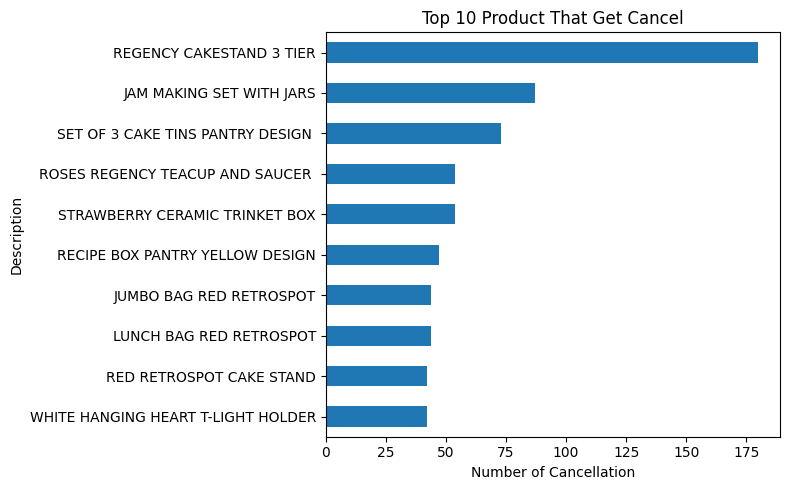

In [55]:
# Product that frequently get cancelled
top_cancelled = (
    df[(df['InvoiceType'] == 'Cancellation') & df['IsProduct']]
    ['Description'].value_counts().head(10)
)
print(top_cancelled)
print()

top_cancelled.plot(kind='barh', figsize=(8,5), title='Top 10 Product That Get Cancel')
plt.gca().invert_yaxis()
plt.xlabel('Number of Cancellation')
plt.tight_layout()
plt.show()

In [56]:
# Revenue that loss because of Cancellation or Retur
gross_revenue = df.loc[df['InvoiceType'] == 'Normal', 'Revenue'].sum()
cancelled_revenue = df.loc[df['InvoiceType'] == 'Cancellation', 'Revenue'].sum()  # bernilai negatif
net_revenue = gross_revenue + cancelled_revenue

print(f'Gross revenue (normal transaction)    : {gross_revenue:,.2f}')
print(f'Lost revenue because of cancellation  : {cancelled_revenue:,.2f}')
print(f'Net revenue (gross - cancellation)    : {net_revenue:,.2f}')
print(f'Lost revenue persentace               : {abs(cancelled_revenue)/gross_revenue*100:.2f}%')

Gross revenue (normal transaction)    : 10,220,375.81
Lost revenue because of cancellation  : -483,306.80
Net revenue (gross - cancellation)    : 9,737,069.01
Lost revenue persentace               : 4.73%


### Basket Analysis

In [57]:
basket = (
    df[df['InvoiceType'] == 'Normal']
    .groupby('InvoiceNo')
    .agg(n_unique_items=('StockCode', 'nunique'),
         total_qty=('Quantity', 'sum'),
         order_value=('Revenue', 'sum'))
)
basket.describe()

,n_unique_items,total_qty,order_value
count,22511.000000,22511.000000,22511.000000
mean,23.213584,241.328373,454.016961
std,44.945969,923.430535,1743.207879
min,1.000000,-9600.000000,-38970.000000
25%,3.000000,44.000000,108.175000
50%,13.000000,128.000000,262.150000
75%,26.000000,268.000000,452.275000
max,1110.000000,80995.000000,168469.600000


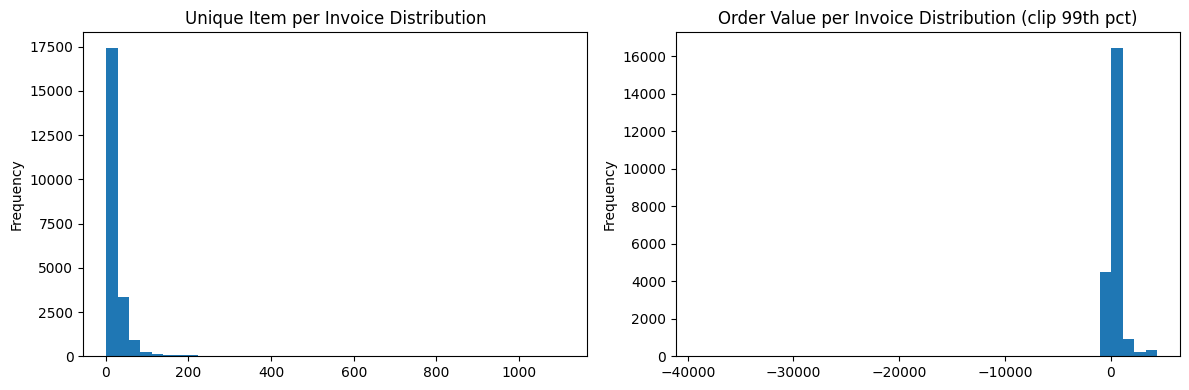

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))
basket['n_unique_items'].plot(kind='hist', bins=40, ax=axes[0], title='Unique Item per Invoice Distribution')
basket['order_value'].clip(upper=basket['order_value'].quantile(0.99)).plot(
    kind='hist', bins=40, ax=axes[1], title='Order Value per Invoice Distribution (clip 99th pct)')
plt.tight_layout()
plt.show()

Korelasi jumlah item unik vs nilai order: 0.274


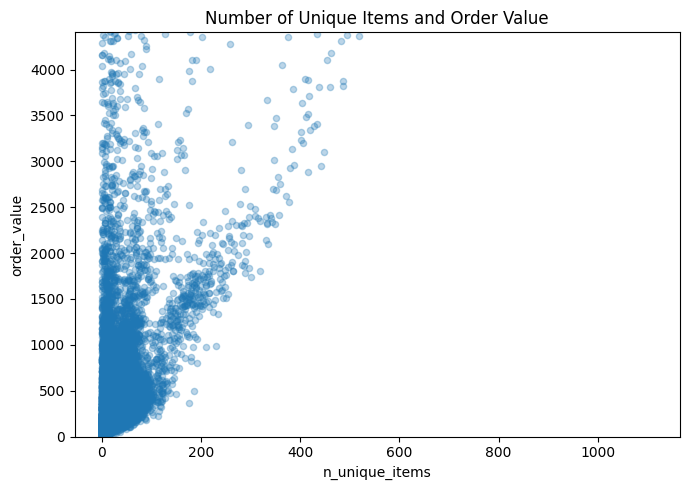

In [59]:
correlation = basket[['n_unique_items', 'order_value']].corr().iloc[0,1]
print(f'Korelasi jumlah item unik vs nilai order: {correlation:.3f}')
basket.plot(kind='scatter', x='n_unique_items', y='order_value', alpha=0.3, figsize=(7,5),
            title='Number of Unique Items and Order Value')
plt.ylim(0, basket['order_value'].quantile(0.99))
plt.tight_layout()
plt.show()

### Revenue Non-Merchandise Proportion

In [60]:
total_revenue = df.loc[df['InvoiceType']=='Normal', 'Revenue'].sum()
non_merch_revenue = df.loc[(df['InvoiceType']=='Normal') & (~df['IsProduct']), 'Revenue'].sum()

print(f'Total revenue tercatat        : {total_revenue:,.2f}')
print(f'Revenue dari non-merchandise   : {non_merch_revenue:,.2f}')
print(f'Persentase non-merchandise     : {non_merch_revenue/total_revenue*100:.2f}%')

Total revenue tercatat        : 10,220,375.81
Revenue dari non-merchandise   : -34,747.87
Persentase non-merchandise     : -0.34%


In [61]:
breakdown = (
    df[(df['InvoiceType']=='Normal') & (~df['IsProduct'])]
    .groupby('StockCode')['Revenue'].sum()
    .sort_values(ascending=False)
)
breakdown

StockCode
DOT          206245.480
POST          66230.640
PADS              0.003
S             -3039.650
D             -5696.220
CRUK          -7933.430
M            -69034.190
AMAZONFEE   -221520.500
Name: Revenue, dtype: float64

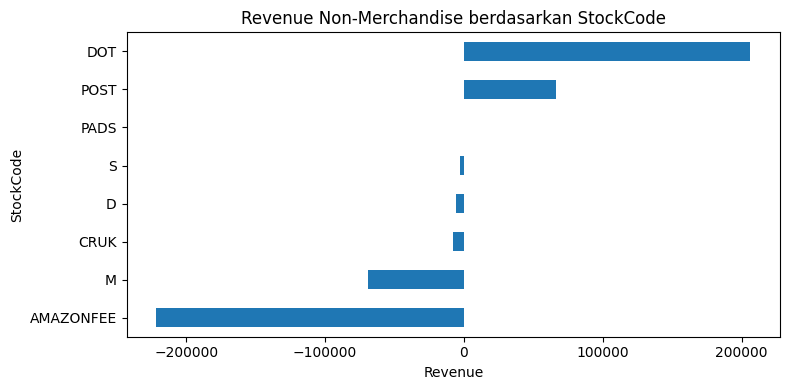

In [62]:
breakdown.plot(kind='barh', figsize=(8,4), title='Revenue Non-Merchandise berdasarkan StockCode')
plt.gca().invert_yaxis()
plt.xlabel('Revenue')
plt.tight_layout()
plt.show()

### 1. Return / Cancellation Analysis 

Dari total transaksi, **return rate (invoice yang dibatalkan) sebesar 14,81%** — cukup tinggi untuk bisnis retail/wholesale, mengindikasikan hampir 1 dari 7 invoice berakhir dengan pembatalan. Rincian tipe invoice:

| Tipe Invoice | Jumlah | Persentase |
|---|---|---|
| Normal | 22.061 | ~85,15% |
| Cancellation | 3.836 | ~14,81% |
| Adjustment | 3 | ~0,01% |

**Produk paling sering dibatalkan** didominasi oleh **Regency Cakestand 3 Tier (180 kali)** — jauh di atas produk lain seperti Jam Making Set with Jars (87) dan Set of 3 Cake Tins Pantry Design (73). Menariknya, produk ini juga masuk **top produk terlaris dan top revenue** di analisis sebelumnya — menunjukkan bahwa volume tinggi cenderung berbanding lurus dengan volume pembatalan, namun tetap layak diperiksa apakah ada masalah spesifik pada produk ini (kualitas, kemasan pecah saat pengiriman, dll) yang menyebabkan tingkat retur lebih tinggi dari proporsional.

**Dampak finansial pembatalan:**
- Gross revenue (transaksi normal): **10.631.048,74**
- Lost revenue akibat cancellation: **-893.979,73**
- Net revenue: **9.737.069,01**
- **Revenue percentage yang hilang: 8,41%**

Kehilangan **8,41% dari total revenue potensial** akibat cancellation adalah angka yang cukup material. Dikombinasikan dengan temuan bahwa produk-produk terlaris justru paling sering dibatalkan, ini menjadi sinyal kuat untuk menelusuri **akar penyebab cancellation** (kualitas produk, kesalahan pengiriman, atau perubahan pikiran pelanggan pada bulk order) guna mengurangi kebocoran revenue ini.

### 2. Basket Analysis 

Statistik deskriptif per invoice (n=22.061 transaksi normal):

| Metrik | Mean | Median | Min | Max |
|---|---|---|---|---|
| Unique items per invoice | 23,67 | 13 | 1 | 1.110 |
| Order value | 481,89 | 271,20 | 0 | 168.469,60 |

**Insight:**
- Distribusi **unique items per invoice** sangat right-skewed — mayoritas invoice hanya berisi sedikit item (median 13), tapi ada outlier ekstrem hingga 1.110 item unik dalam satu invoice, kemungkinan pesanan wholesale/reseller dalam skala besar.
- **Nilai minimum order_value adalah 0**, yang perlu diperiksa lebih lanjut — kemungkinan ada invoice dengan produk gratis/promo, atau indikasi data anomali yang perlu dibersihkan.
- Distribusi **order value** juga right-skewed dengan ekor panjang hingga puncak di sekitar >4.000 (kemungkinan cluster outlier bulk order yang sama seperti temuan di analisis geografi/pelanggan sebelumnya, misalnya CustomerID 16446 dan produk Regency Cakestand).
- **Korelasi antara jumlah item unik dan nilai order hanya 0,276** — tergolong **lemah**. Artinya, banyaknya variasi produk dalam satu invoice **tidak serta-merta menentukan besarnya nilai transaksi**; nilai order lebih dipengaruhi oleh kuantitas per item dan harga satuan produk yang dibeli, bukan keragaman jenis produknya. Ini terlihat jelas pada scatter plot, di mana order value tinggi bisa muncul meski n_unique_items rendah (order besar tapi terkonsentrasi pada sedikit jenis produk).

### 3. Proporsi Revenue Non-Merchandise 

- Total revenue tercatat: **10.631.048,74**
- Revenue dari non-merchandise: **375.925,06**
- **Persentase non-merchandise: 3,54%**

Rincian StockCode non-merchandise:

| StockCode | Revenue | Keterangan |
|---|---|---|
| DOT | 206.248,77 | kemungkinan biaya pengiriman (dotcom postage) |
| POST | 78.101,88 | biaya pos/pengiriman |
| M | 77.750,27 | manual entry/adjustment |
| AMAZONFEE | 13.761,09 | biaya platform Amazon |
| S | 63,00 | sample |
| PADS | 0,003 | biaya administratif kecil |

**Insight:**
Meski proporsinya kecil (3,54%) terhadap total revenue, komponen **non-merchandise** ini penting untuk dipisahkan dari analisis performa produk agar tidak mendistorsi metrik seperti revenue per produk atau AOV. **DOT (dotcom postage)** menjadi kontributor terbesar non-merchandise (206.248,77) — mengindikasikan biaya pengiriman untuk kanal online (dotcom) cukup signifikan dan sudah dibebankan sebagai baris revenue tersendiri, bukan digabung ke harga produk. Untuk analisis revenue produk murni (yang sudah dilakukan di bagian Product Analysis sebelumnya), item-item non-merchandise ini idealnya memang dikecualikan — sehingga temuan revenue produk di bagian sebelumnya tetap valid dan bersih dari noise biaya operasional ini.

# 6. Customer Churn Classification

## 6.1 Data Analysis Before Building Model

           Quantity  UnitPrice   Revenue
Quantity   1.000000  -0.390376  0.689437
UnitPrice -0.390376   1.000000  0.324276
Revenue    0.689437   0.324276  1.000000
     Feature       VIF
0   Quantity  5.192819
1  UnitPrice  1.136686
2    Revenue  5.328219


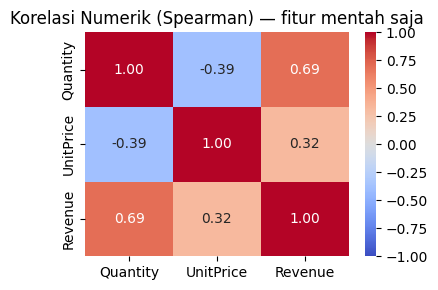

In [63]:
# =========================================================
# 1. NUMERIK vs NUMERIK — Spearman + VIF (khusus fitur kandidat model, exclude Revenue)
# =========================================================
num_cols = ['Quantity', 'UnitPrice', 'Revenue']  

corr_num = df[num_cols].corr(method='spearman')
print(corr_num)

X_vif = df[num_cols].dropna()
vif_data = pd.DataFrame({
    'Feature': num_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
})
print(vif_data)  # VIF > 5-10 -> indikasi multicollinearity kuat

plt.figure(figsize=(4,3))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi Numerik (Spearman) — fitur mentah saja')
plt.tight_layout()
plt.show()

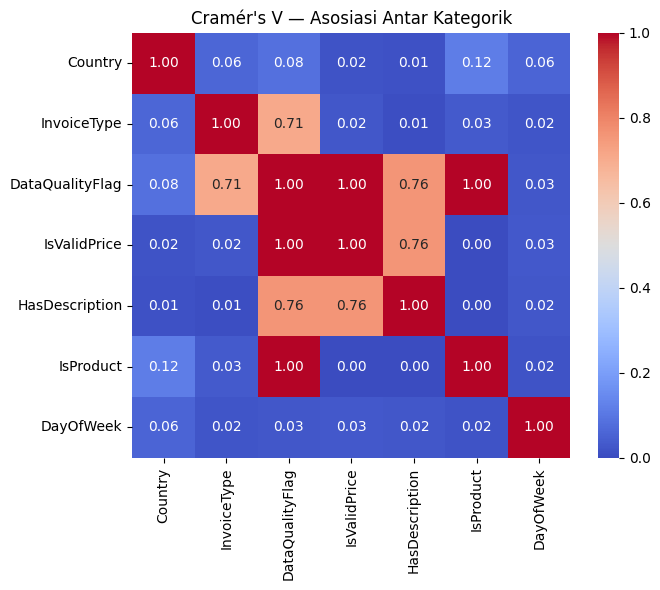

In [64]:
# =========================================================
# 2. KATEGORIK vs KATEGORIK — Cramér's V matrix (ganti heatmap Spearman-encoded)
# =========================================================
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Pilih HANYA kolom kategorik yang secara makna relevan (bukan ID/text bebas)
cat_cols = ['Country', 'InvoiceType', 'DataQualityFlag', 'IsValidPrice', 'HasDescription', 'IsProduct', 'DayOfWeek']

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramers_matrix.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(df[c1], df[c2])

plt.figure(figsize=(7,6))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title("Cramér's V — Asosiasi Antar Kategorik")
plt.tight_layout()
plt.show()

In [65]:
# =========================================================
# 3. NUMERIK vs KATEGORIK — Kruskal-Wallis + effect size (epsilon-squared)
# =========================================================
def kruskal_effect_size(df, num_col, group_col):
    groups = [g[num_col].dropna().values for _, g in df.groupby(group_col)]
    stat, p = kruskal(*groups)
    n = sum(len(g) for g in groups)
    k = len(groups)
    epsilon_sq = (stat - k + 1) / (n - k)  # 0 = tidak ada efek, mendekati 1 = efek besar
    return stat, p, epsilon_sq

cat_cols = df.select_dtypes(include=['object', 'bool']).columns.to_list()
cat_cols = set(cat_cols) - set(['InvoiceNo', 'StockCode', 'Description', 'CustomerID'])
num_cols = df.select_dtypes(include=['number']).columns.to_list()

for num_col in num_cols:
    for group_col in cat_cols:
        stat, p, eps = kruskal_effect_size(df, num_col, group_col)
        print(f'{num_col} by {group_col}: H={stat:.1f}, p={p:.4g}, epsilon²={eps:.4f}')

Quantity by Country: H=25047.0, p=0, epsilon²=0.0466
Quantity by DataQualityFlag: H=30539.8, p=0, epsilon²=0.0569
Quantity by IsValidPrice: H=1941.2, p=0, epsilon²=0.0036
Quantity by HasDescription: H=1084.4, p=8.12e-238, epsilon²=0.0020
Quantity by IsProduct: H=2216.4, p=0, epsilon²=0.0041
Quantity by DayOfWeek: H=2030.7, p=0, epsilon²=0.0038
Quantity by InvoiceType: H=26091.8, p=0, epsilon²=0.0486
UnitPrice by Country: H=890.9, p=5.591e-163, epsilon²=0.0016
UnitPrice by DataQualityFlag: H=13180.9, p=0, epsilon²=0.0246
UnitPrice by IsValidPrice: H=7514.5, p=0, epsilon²=0.0140
UnitPrice by HasDescription: H=4340.9, p=0, epsilon²=0.0081
UnitPrice by IsProduct: H=5311.5, p=0, epsilon²=0.0099
UnitPrice by DayOfWeek: H=1662.8, p=0, epsilon²=0.0031
UnitPrice by InvoiceType: H=459.4, p=1.783e-100, epsilon²=0.0009
Revenue by Country: H=26576.9, p=0, epsilon²=0.0495
Revenue by DataQualityFlag: H=33660.6, p=0, epsilon²=0.0627
Revenue by IsValidPrice: H=6991.2, p=0, epsilon²=0.0130
Revenue by Ha

In [66]:
rfm.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4336 entries, 0 to 4335
Data columns (total 10 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   CustomerID  4336 non-null   object  
 1   Recency     4336 non-null   int64   
 2   Frequency   4336 non-null   int64   
 3   Monetary    4336 non-null   float64 
 4   R_score     4336 non-null   category
 5   F_score     4336 non-null   category
 6   M_score     4336 non-null   category
 7   RFM_score   4336 non-null   object  
 8   Segment     4336 non-null   object  
 9   Churn       4336 non-null   object  
dtypes: category(3), float64(1), int64(2), object(4)
memory usage: 250.6+ KB


            Recency  Frequency  Monetary
Recency    1.000000  -0.562794 -0.480729
Frequency -0.562794   1.000000  0.806403
Monetary  -0.480729   0.806403  1.000000
     Feature       VIF
0    Recency  1.028528
1  Frequency  1.534025
2   Monetary  1.499593


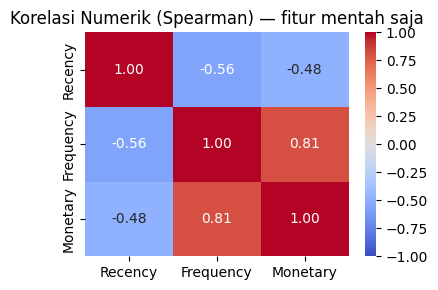

In [67]:
num_cols = rfm.select_dtypes(include='number').columns.to_list() 

corr_num = rfm[num_cols].corr(method='spearman')
print(corr_num)

X_vif = rfm[num_cols].dropna()
vif_data = pd.DataFrame({
    'Feature': num_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
})
print(vif_data)  # VIF > 5-10 -> indikasi multicollinearity kuat

plt.figure(figsize=(4,3))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi Numerik (Spearman) — fitur mentah saja')
plt.tight_layout()
plt.show()

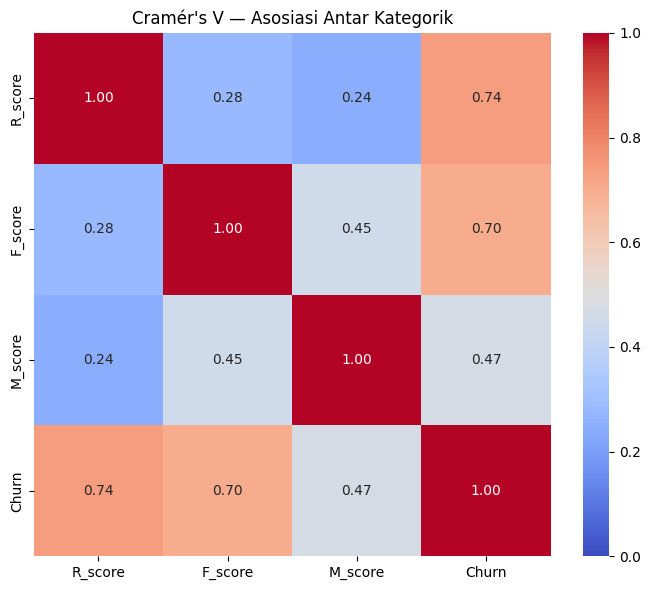

In [68]:
# Pilih HANYA kolom kategorik yang secara makna relevan (bukan ID/text bebas)
cat_cols = rfm.select_dtypes(include=['category', 'object']).columns.to_list()
cat_cols.remove('CustomerID')
cat_cols.remove('RFM_score')
cat_cols.remove('Segment')

cramers_matrix = pd.DataFrame(index=cat_cols, columns=cat_cols, dtype=float)
for c1 in cat_cols:
    for c2 in cat_cols:
        cramers_matrix.loc[c1, c2] = 1.0 if c1 == c2 else cramers_v(rfm[c1], rfm[c2])

plt.figure(figsize=(7,6))
sns.heatmap(cramers_matrix.astype(float), annot=True, cmap='coolwarm', fmt='.2f', vmin=0, vmax=1)
plt.title("Cramér's V — Asosiasi Antar Kategorik")
plt.tight_layout()
plt.show()

## 6.2 Feature Engineering

### 6.2.1 Time-Based Split for Churn Labeling

In [69]:
df_normal = df[(df['InvoiceType'] == 'Normal') & df['CustomerID'].notna()].copy()

In [70]:
max_date = df_normal['InvoiceDate'].max()
threshold_date = max_date - pd.Timedelta(days=90)

feature_df = df_normal[df_normal['InvoiceDate'] < threshold_date]
outcome_df = df_normal[df_normal['InvoiceDate'] >= threshold_date]

print(f'Threshold Date: {threshold_date}')
print(f'Feature Periode: {feature_df['InvoiceDate'].min()} - {feature_df['InvoiceDate'].max()}')
print(f'Outcome Periode: {outcome_df['InvoiceDate'].min()} - {outcome_df['InvoiceDate'].max()}')
print(f'Customer in Feature Data: {feature_df['CustomerID'].nunique()}')
print(f'Customer in Outcome Data: {outcome_df['CustomerID'].nunique()}')

Threshold Date: 2011-09-10 12:50:00
Feature Periode: 2010-12-01 08:26:00 - 2011-09-09 15:53:00
Outcome Periode: 2011-09-11 10:35:00 - 2011-12-09 12:50:00
Customer in Feature Data: 3380
Customer in Outcome Data: 2891


In [71]:
new_cus = set(outcome_df['CustomerID']) - set(feature_df['CustomerID'])
print(f'New Customer (spot in outcome data): {len(new_cus)}')

New Customer (spot in outcome data): 966


In [72]:
active_cus = feature_df['CustomerID'].unique()
cus_data = feature_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (threshold_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('Revenue', 'sum'),
    Tenure=('InvoiceDate', lambda x: (threshold_date - x.min()).days),
    AvgBasketSize=('StockCode', lambda x: x.nunique() / feature_df.loc[x.index, 'InvoiceNo'].nunique()),
    NumUniqueProducts=('StockCode', 'nunique'),
    Country=('Country', lambda x: x.mode()[0]),
).reset_index()

cus_data['AvgOrderValue'] = cus_data['Monetary'] / cus_data['Frequency']

cust_all = df[(df['CustomerID'].isin(active_cus)) & (df['InvoiceDate'] < threshold_date)]
cancel_rate = (
    cust_all.groupby('CustomerID')['InvoiceType'].apply(lambda x: (x == 'Cancellation')
                                                       .mean()).rename('CancelRate')
)

cus_data = cus_data.merge(cancel_rate, on='CustomerID', how='left').fillna({'CancelRate': 0})

In [73]:
returning_customers = set(outcome_df['CustomerID'].unique())
cus_data['Churn'] = (~cus_data['CustomerID'].isin(returning_customers)).astype(int) # 1: Churn / 0: Non-Churn

In [74]:
print(cus_data['Churn'].value_counts())
print(cus_data.shape)
cus_data.head()

Churn
0    1925
1    1455
Name: count, dtype: int64
(3380, 11)


,CustomerID,Recency,Frequency,Monetary,Tenure,AvgBasketSize,NumUniqueProducts,Country,AvgOrderValue,CancelRate,Churn
0,12346.0,235,1,77183.60,235,1.000000,1,United Kingdom,77183.600000,0.500000,1
1,12347.0,39,5,2790.86,276,16.400000,82,Iceland,558.172000,0.000000,0
2,12348.0,158,3,1487.24,267,7.333333,22,Finland,495.746667,0.000000,0
3,12350.0,219,1,334.40,219,17.000000,17,Norway,334.400000,0.000000,1
4,12352.0,171,7,721.51,206,3.714286,26,Norway,103.072857,0.145833,0


### 6.2.2 Data Correlations

             Feature       VIF
0            Recency  3.861102
1          Frequency  4.260981
2           Monetary  1.869874
3             Tenure  5.335449
4      AvgBasketSize  2.977979
5  NumUniqueProducts  5.121066
6      AvgOrderValue  1.338876
7         CancelRate  1.183675
8              Churn  1.803889


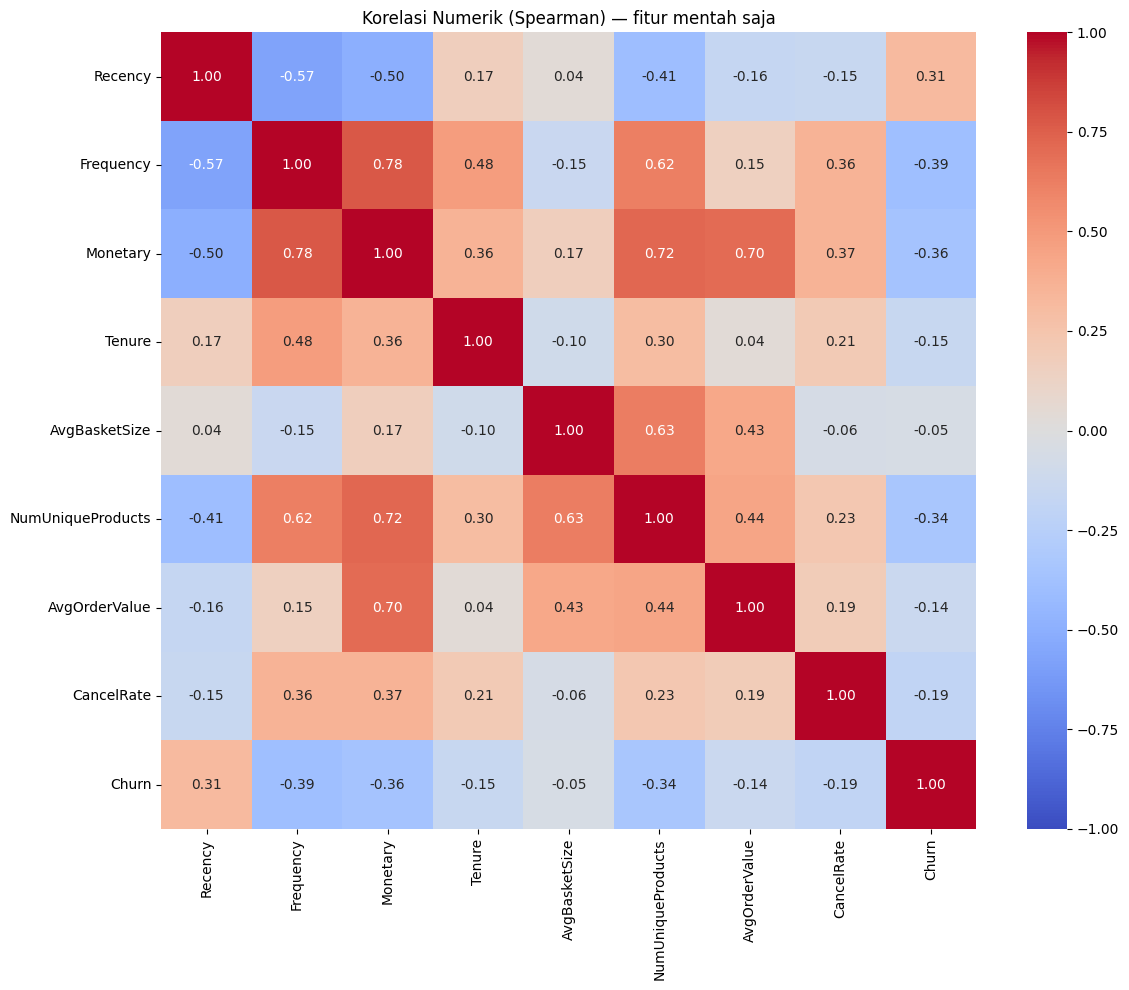

In [75]:
num_cols = cus_data.select_dtypes(include='number').columns.to_list()

corr_num = cus_data[num_cols].corr(method='spearman')

X_vif = cus_data[num_cols].dropna()
vif_data = pd.DataFrame({
    'Feature': num_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(num_cols))]
})
print(vif_data)  # VIF > 5-10 -> indikasi multicollinearity kuat

plt.figure(figsize=(12,10))
sns.heatmap(corr_num, annot=True, cmap='coolwarm', fmt='.2f', vmin=-1, vmax=1)
plt.title('Korelasi Numerik (Spearman) — fitur mentah saja')
plt.tight_layout()
plt.show()

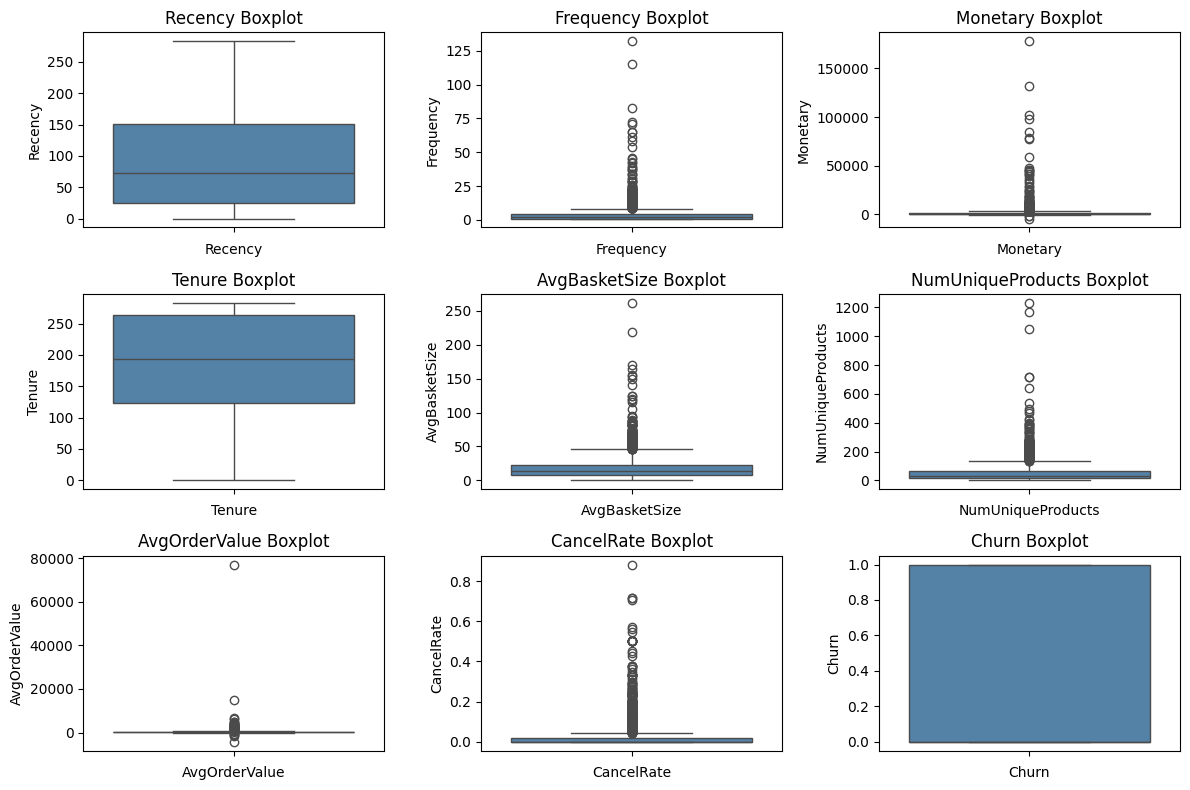

In [76]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(cus_data[col], ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Boxplot')
    axes[i].set_xlabel(col)

plt.tight_layout()
plt.show()

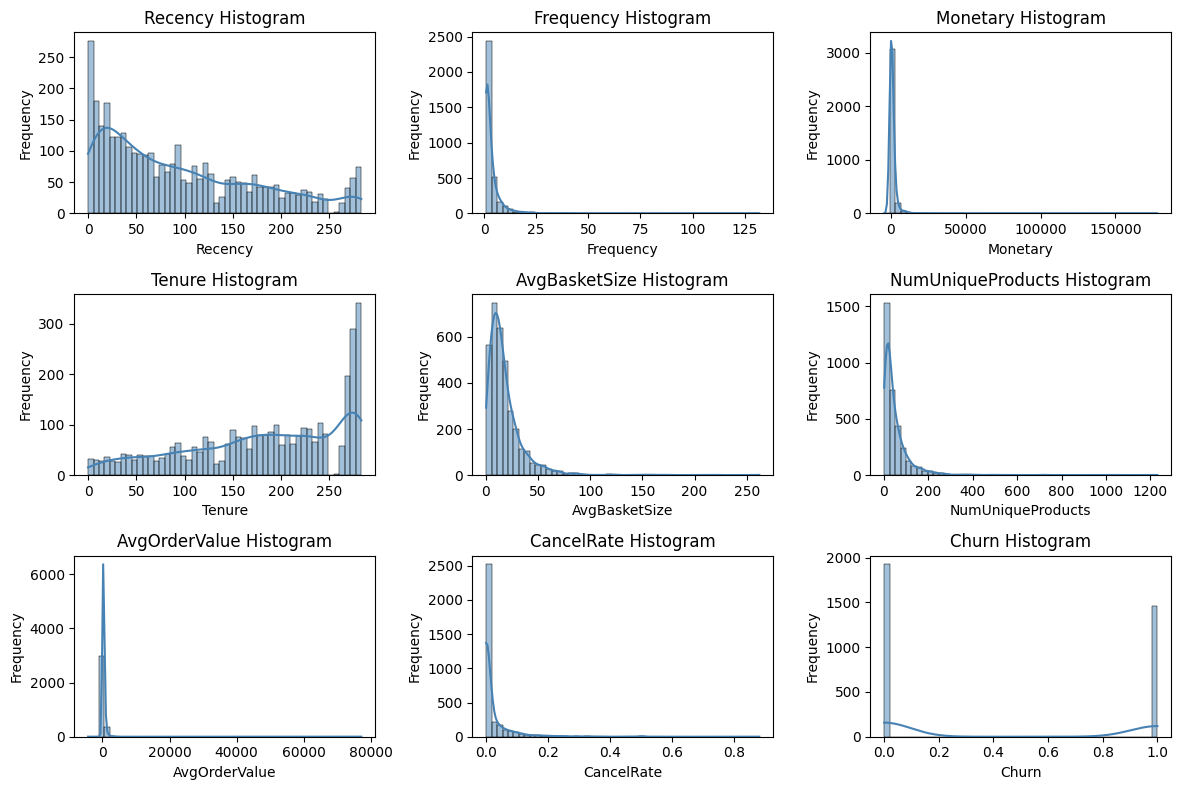

In [77]:
fig, axes = plt.subplots(3, 3, figsize=(12, 8))

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(cus_data[col], kde=True, bins=50, ax=axes[i], color='steelblue')
    axes[i].set_title(f'{col} Histogram')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [78]:
cus_data['Country'].value_counts().count()

np.int64(36)

## 6.3 Spliting Data For Builing Model

In [79]:
x = cus_data.drop(['CustomerID', 'Churn'], axis = 1)
y = cus_data['Churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, stratify = y, random_state = SEED)
print(f'Train data size: {x_train.shape}')
print(f'Test data size: {x_test.shape}')
print(f'Train, Test target size: {y_train.shape, y_test.shape}')

Train data size: (2704, 9)
Test data size: (676, 9)
Train, Test target size: ((2704,), (676,))


## 6.4 Preprocessing

In [80]:
num_cols = x_train.select_dtypes(include='number').columns.to_list()
cat_cols = x_train.select_dtypes(include='object').columns.to_list()

preprocessor = ColumnTransformer(transformers=[
    ('num', 'passthrough', num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

## 6.5 Initial Model

In [81]:
neg, pos = (y_train == 0).sum(), (y_train == 1).sum()
xgb_scale = neg / pos

In [82]:
xgb = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', XGBClassifier(
        objective='binary:logistic',
        eval_metric='logloss',
        random_state=SEED,
        device='cuda',
        scale_pos_weight=xgb_scale
    ))
])

lgbm = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LGBMClassifier(
        objective='binary',
        verbosity=-1,
        random_state=SEED,
        device='gpu',
        class_weight='balanced'
    ))
])

cbc = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', CatBoostClassifier(
        loss_function='Logloss',
        eval_metric='Logloss',
        verbose=False,
        random_seed=SEED,
        task_type='GPU',
        auto_class_weights='Balanced'
    ))
])

## 6.6 Build Model

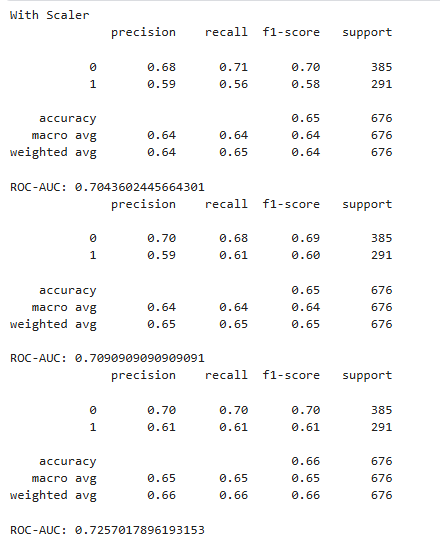 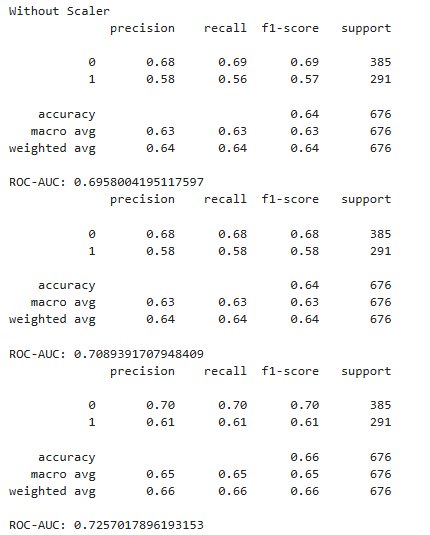

Tidak ada perbedaan dengan atau tidak adanya scaler hanya ada sedikit perbedaan tapi tidak berpengaruh signifikan kedalam cara model membaca pola data

Perbedaan nilai pada model xgb dan lgbm (model 1 & 2, dengan scaler) terlihat lebih besar tapi pada model catboost (model 3) hasil spesifik sama, hal ini menunjukkan perbedaan pada model 1 & 2 hanya hasil dari noise pada randomness yang ada pada metode tree pada umumnya, karena itu di putuskan hanya akan digunakan metode tanpa scaler pada preprocessing data

In [83]:
t0 = time()
xgb.fit(x_train, y_train)
t1 = time()
print(t1 - t0)

lgbm.fit(x_train, y_train)
t2 = time()
print(t2 - t1)

cbc.fit(x_train, y_train)
t3 = time()
print(t3 - t2)

0.9047682285308838


1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.
1 warning generated.


5.616020202636719
26.087197303771973


## 6.7 Model Evaluation

XGBClassifier (xgb)
              precision    recall  f1-score   support

           0       0.69      0.66      0.67       385
           1       0.57      0.60      0.59       291

    accuracy                           0.64       676
   macro avg       0.63      0.63      0.63       676
weighted avg       0.64      0.64      0.64       676

ROC-AUC: 0.6958807515508547


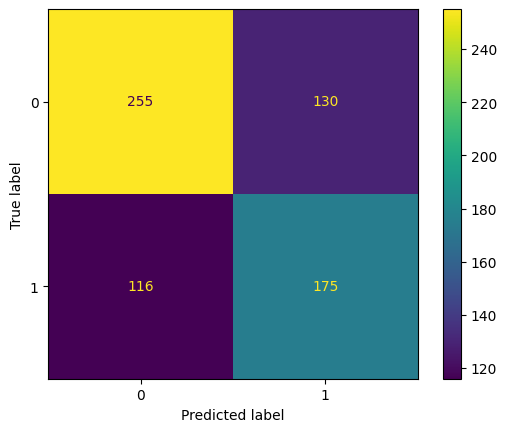

In [84]:
# xgb

y_pred_xgb = xgb.predict(x_test)
y_proba_xgb = xgb.predict_proba(x_test)[:, 1]

print("XGBClassifier (xgb)")
print(classification_report(y_test, y_pred_xgb))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_xgb))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_xgb)
plt.show()

LGBMClassifier (lgbm)
              precision    recall  f1-score   support

           0       0.70      0.62      0.66       385
           1       0.56      0.64      0.60       291

    accuracy                           0.63       676
   macro avg       0.63      0.63      0.63       676
weighted avg       0.64      0.63      0.63       676

ROC-AUC: 0.7083322176105682


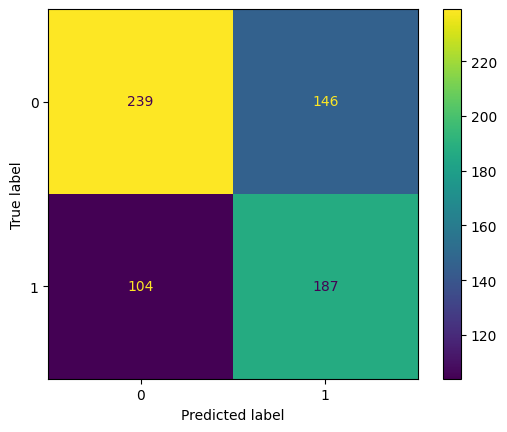

In [85]:
# lgbm

y_pred_lgbm = lgbm.predict(x_test)
y_proba_lgbm = lgbm.predict_proba(x_test)[:, 1]

print("LGBMClassifier (lgbm)")
print(classification_report(y_test, y_pred_lgbm))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_lgbm))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_lgbm)
plt.show()

CatBoostClassifier (cbc)
              precision    recall  f1-score   support

           0       0.73      0.62      0.67       385
           1       0.58      0.69      0.63       291

    accuracy                           0.65       676
   macro avg       0.65      0.66      0.65       676
weighted avg       0.66      0.65      0.65       676

ROC-AUC: 0.7251394653456509


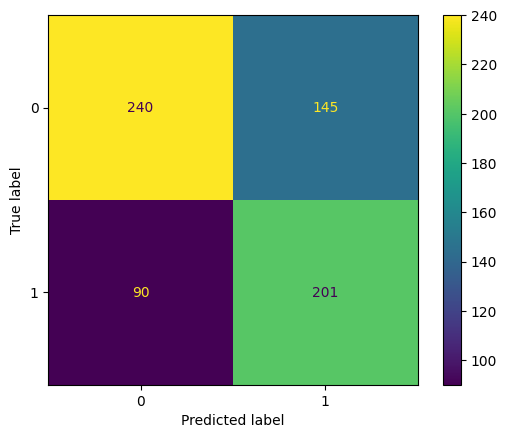

In [86]:
# cbc

y_pred_cbc = cbc.predict(x_test)
y_proba_cbc = cbc.predict_proba(x_test)[:, 1]

print('CatBoostClassifier (cbc)')
print(classification_report(y_test, y_pred_cbc))
print('ROC-AUC:', roc_auc_score(y_test, y_proba_cbc))

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_cbc)
plt.show()

## 6.8 Hyperparameter Fine-Tuning (Grid Search)
RandomizeSearchCV (untuk parameter secara luas) -> GridSeacrhCV dari hasil percobaan -> cross_val_score untuk evaluasi

In [87]:
param_dist = {
    'classifier__iterations': [200, 300, 500, 800],
    'classifier__depth': [4, 6, 8, 10],
    'classifier__learning_rate': [0.01, 0.03, 0.05, 0.1],
    'classifier__l2_leaf_reg': [1, 3, 5, 7, 9],
    'classifier__border_count': [32, 64, 128],
    'classifier__bagging_temperature': [0, 0.5, 1, 2],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)  # stratify penting karena imbalance

random_search = RandomizedSearchCV(
    estimator=cbc,
    param_distributions=param_dist,
    n_iter=50,
    scoring='roc_auc',       
    cv=cv,
    n_jobs=1,
    verbose=2,
    random_state=SEED
)

random_search.fit(x_train, y_train)

print('Best params:', random_search.best_params_)
print('Best CV ROC-AUC:', random_search.best_score_)

best_model = random_search.best_estimator_

Fitting 5 folds for each of 50 candidates, totalling 250 fits
[CV] END classifier__bagging_temperature=0, classifier__border_count=128, classifier__depth=6, classifier__iterations=300, classifier__l2_leaf_reg=3, classifier__learning_rate=0.05; total time=   3.0s
[CV] END classifier__bagging_temperature=0, classifier__border_count=128, classifier__depth=6, classifier__iterations=300, classifier__l2_leaf_reg=3, classifier__learning_rate=0.05; total time=   3.1s
[CV] END classifier__bagging_temperature=0, classifier__border_count=128, classifier__depth=6, classifier__iterations=300, classifier__l2_leaf_reg=3, classifier__learning_rate=0.05; total time=   2.9s
[CV] END classifier__bagging_temperature=0, classifier__border_count=128, classifier__depth=6, classifier__iterations=300, classifier__l2_leaf_reg=3, classifier__learning_rate=0.05; total time=   2.8s
[CV] END classifier__bagging_temperature=0, classifier__border_count=128, classifier__depth=6, classifier__iterations=300, classifier_

In [88]:
cv_results = pd.DataFrame(random_search.cv_results_)
cv_results = cv_results.sort_values('mean_test_score', ascending=False)

top_n = cv_results.head(3)[[
    'mean_test_score', 'std_test_score',
    'param_classifier__iterations',
    'param_classifier__depth',
    'param_classifier__learning_rate',
    'param_classifier__l2_leaf_reg',
    'param_classifier__border_count',
    'param_classifier__bagging_temperature',
]]
top_n

,mean_test_score,std_test_score,param_classifier__iterations,param_classifier__depth,param_classifier__learning_rate,param_classifier__l2_leaf_reg,param_classifier__border_count,param_classifier__bagging_temperature
26,0.754078,0.018704,500,4,0.01,3,64,1.0
13,0.753982,0.016534,800,4,0.01,1,128,0.5
8,0.753270,0.019862,500,6,0.01,9,128,1.0


In [89]:
param_grid = {
    'classifier__iterations': [500, 800],
    'classifier__depth': [4, 6],
    'classifier__learning_rate': [0.01],
    'classifier__l2_leaf_reg': [1, 3, 9],
    'classifier__border_count': [64, 128],
    'classifier__bagging_temperature': [0.5, 1.0]
}

grid_search = GridSearchCV(
    estimator=cbc,
    param_grid=param_grid,
    scoring='roc_auc',
    cv=cv,
    n_jobs=1,
    verbose=2
)

grid_search.fit(x_train, y_train)
print('Best params:', grid_search.best_params_)

Fitting 5 folds for each of 48 candidates, totalling 240 fits
[CV] END classifier__bagging_temperature=0.5, classifier__border_count=64, classifier__depth=4, classifier__iterations=500, classifier__l2_leaf_reg=1, classifier__learning_rate=0.01; total time=   9.4s
[CV] END classifier__bagging_temperature=0.5, classifier__border_count=64, classifier__depth=4, classifier__iterations=500, classifier__l2_leaf_reg=1, classifier__learning_rate=0.01; total time=   9.9s
[CV] END classifier__bagging_temperature=0.5, classifier__border_count=64, classifier__depth=4, classifier__iterations=500, classifier__l2_leaf_reg=1, classifier__learning_rate=0.01; total time=  10.7s
[CV] END classifier__bagging_temperature=0.5, classifier__border_count=64, classifier__depth=4, classifier__iterations=500, classifier__l2_leaf_reg=1, classifier__learning_rate=0.01; total time=  10.4s
[CV] END classifier__bagging_temperature=0.5, classifier__border_count=64, classifier__depth=4, classifier__iterations=500, classi

## 6.9 Evaluate Best Model

In [90]:
best_model = grid_search.best_estimator_
y_pred = best_model.predict(x_test)
y_proba = best_model.predict_proba(x_test)[:, 1]

print(classification_report(y_test, y_pred))
print('ROC-AUC:', roc_auc_score(y_test, y_proba))

              precision    recall  f1-score   support

           0       0.75      0.61      0.67       385
           1       0.58      0.73      0.65       291

    accuracy                           0.66       676
   macro avg       0.67      0.67      0.66       676
weighted avg       0.68      0.66      0.66       676

ROC-AUC: 0.7313607354844468


## 7.0 Threshold Tuning

In [91]:
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)

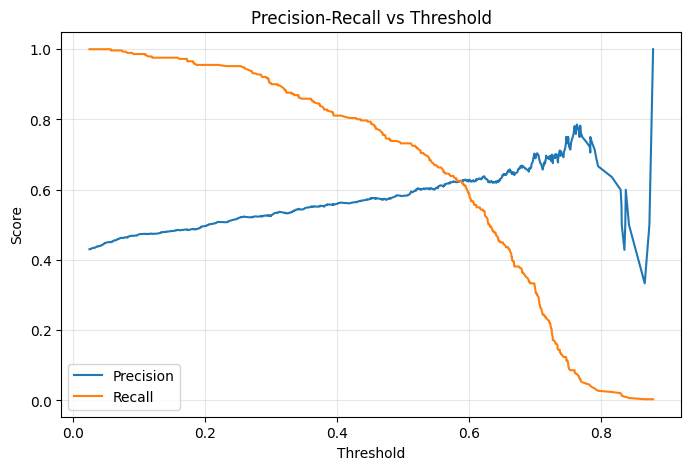

In [92]:
plt.figure(figsize=(8,5))
plt.plot(thresholds, precision[:-1], label='Precision')
plt.plot(thresholds, recall[:-1], label='Recall')
plt.xlabel('Threshold')
plt.ylabel('Score')
plt.title('Precision-Recall vs Threshold')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [93]:
target_recall = 0.80
idx = np.where(recall[:-1] >= target_recall)[0]
best_idx = idx[np.argmax(precision[:-1][idx])]  
best_threshold = thresholds[best_idx]
print(f'Threshold: {best_threshold:.3f}, Precision: {precision[best_idx]:.3f}, Recall: {recall[best_idx]:.3f}')

Threshold: 0.435, Precision: 0.568, Recall: 0.801


In [94]:
f1_scores = 2 * (precision[:-1] * recall[:-1]) / (precision[:-1] + recall[:-1] + 1e-9)
best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx]
print(f'Threshold optimal (max F1): {best_threshold:.3f}')

Threshold optimal (max F1): 0.259


              precision    recall  f1-score   support

           0       0.90      0.35      0.50       385
           1       0.52      0.95      0.67       291

    accuracy                           0.61       676
   macro avg       0.71      0.65      0.59       676
weighted avg       0.74      0.61      0.58       676



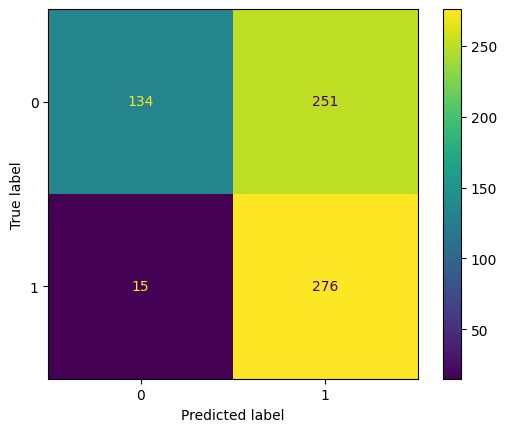

In [95]:
y_pred_tuned = (y_proba >= best_threshold).astype(int)

print(classification_report(y_test, y_pred_tuned))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tuned)
plt.show()

## 7.1 Feature Importance

### 7.1.1 get_feature_importance

<Axes: >

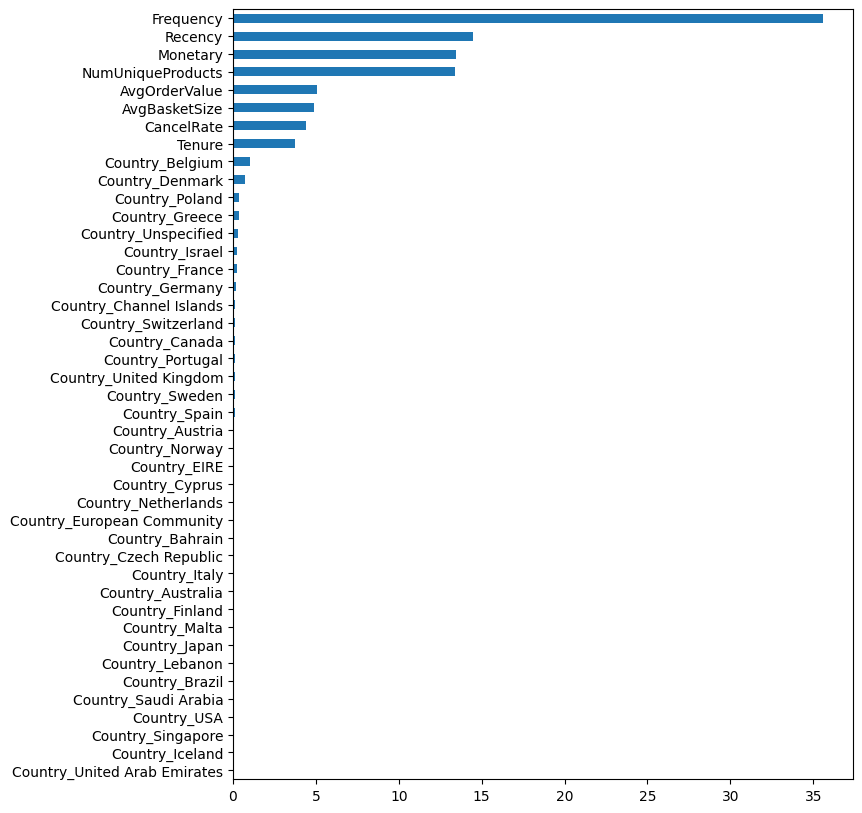

In [96]:
importances = best_model.named_steps['classifier'].get_feature_importance()
feature_names = (num_cols + list(
    best_model.named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols)
))
pd.Series(importances, index=feature_names).sort_values().plot(kind='barh', figsize=(8,10))

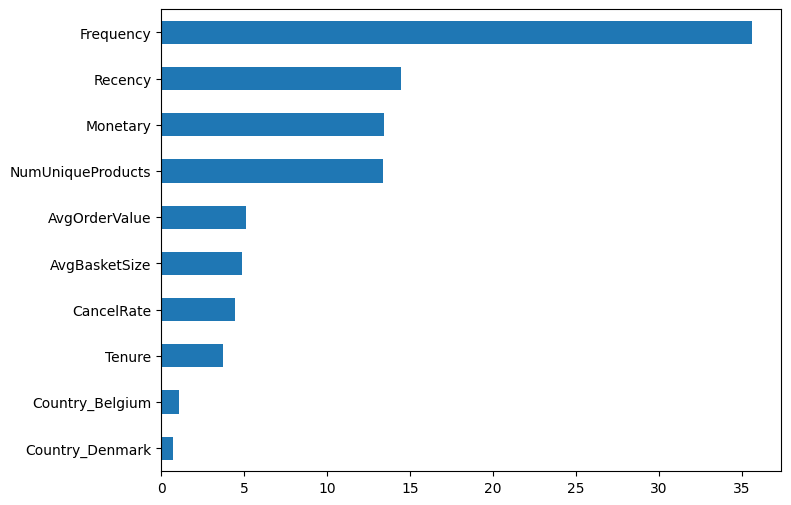

In [97]:
pd.Series(importances, index=feature_names).sort_values(ascending=False).head(10).plot(kind='barh', figsize=(8,6))
plt.gca().invert_yaxis()

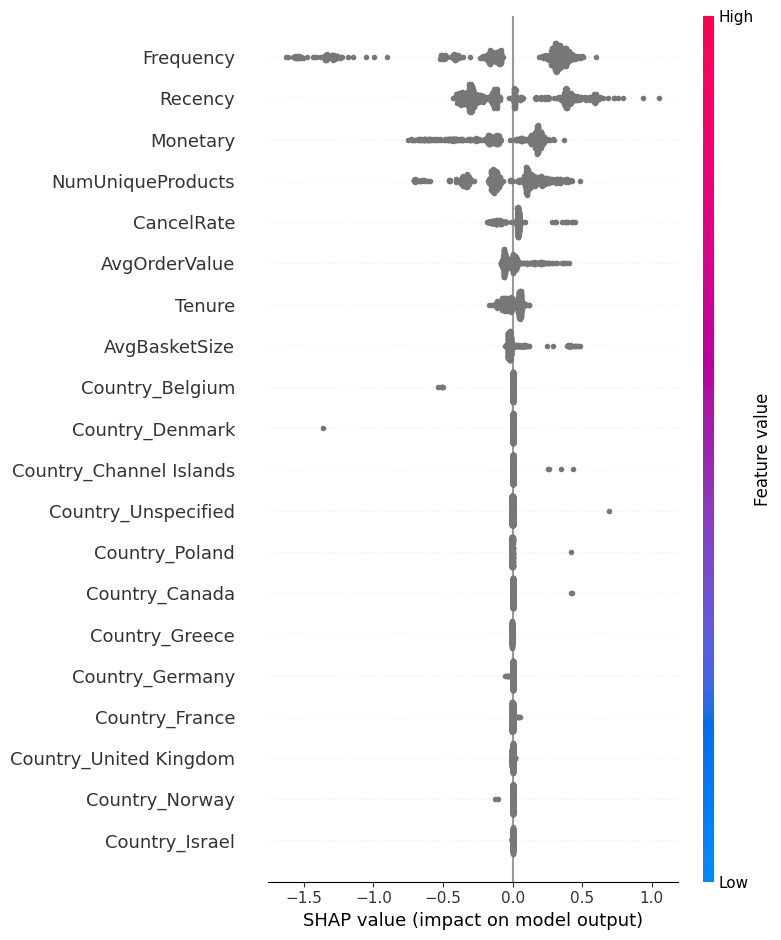

In [98]:
explainer = shap.TreeExplainer(best_model.named_steps['classifier'])
x_test_transformed = best_model.named_steps['preprocessor'].transform(x_test)
shap_values = explainer.shap_values(x_test_transformed)

shap.summary_plot(shap_values, x_test_transformed, feature_names=feature_names)

In [99]:
cus_data['churn_probability'] = best_model.predict_proba(x)[:, 1]
cus_data['risk_tier'] = pd.cut(cus_data['churn_probability'], bins=[0, 0.3, 0.7, 1], labels=['Low', 'Medium', 'High'])

In [100]:
cus_data

,CustomerID,Recency,Frequency,Monetary,Tenure,AvgBasketSize,NumUniqueProducts,Country,AvgOrderValue,CancelRate,Churn,churn_probability,risk_tier
0,12346.0,235,1,77183.60,235,1.000000,1,United Kingdom,77183.600000,0.500000,1,0.895982,High
1,12347.0,39,5,2790.86,276,16.400000,82,Iceland,558.172000,0.000000,0,0.161937,Low
2,12348.0,158,3,1487.24,267,7.333333,22,Finland,495.746667,0.000000,0,0.511462,Medium
3,12350.0,219,1,334.40,219,17.000000,17,Norway,334.400000,0.000000,1,0.733680,High
4,12352.0,171,7,721.51,206,3.714286,26,Norway,103.072857,0.145833,0,0.295736,Low
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3375,18280.0,187,1,180.60,187,10.000000,10,United Kingdom,180.600000,0.000000,1,0.725282,High
3376,18281.0,90,1,80.82,90,7.000000,7,United Kingdom,80.820000,0.000000,1,0.683725,Medium
3377,18282.0,35,1,100.21,35,7.000000,7,United Kingdom,100.210000,0.125000,0,0.588104,Medium
3378,18283.0,5,10,1086.83,246,19.200000,192,United Kingdom,108.683000,0.000000,0,0.079749,Low


In [101]:
joblib.dump(best_model, 'churn_model.pkl')

['churn_model.pkl']